In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:
from google.colab import files

uploaded = files.upload()


Saving lunar.v3i.coco.zip to lunar.v3i.coco.zip


In [3]:
!ls -lh

total 69M
-rw-r--r-- 1 root root  69M Aug 29 04:20 lunar.v3i.coco.zip
drwxr-xr-x 1 root root 4.0K Aug 24 13:21 sample_data


In [4]:
!mkdir -p /content/lunar_data
!unzip -q lunar.v3i.coco.zip -d /content/lunar_data

In [5]:
!find /content/lunar_data -maxdepth 2 -type f | head -30

/content/lunar_data/README.dataset.txt
/content/lunar_data/test/ch2_tmc_ncn_20220719T0152362943_b_brw_d1814_jpeg.rf.c40bed95c180e2e4553c12c2261c3a7a.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220523T0238375485_b_brw_d1824_jpeg.rf.ba3e2f1f5ad2d10c8c0301399cc483cb.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220529T0906489752_b_brw_d186_jpeg.rf.fd6a7bbdd6130377d1ad4d4f39b6ccb8.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220601T0621413366_b_brw_d3235_jpeg.rf.5194592a9d9f2ba6bb06df0945bbde15.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220603T1019273042_b_brw_d328_jpeg.rf.b4fe19159bb746a6c94be7ad54fc6d7a.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220531T0832375420_b_brw_d3218_jpeg.rf.26221ff3860cad61b8e9893286add0b3.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220527T0134064246_b_brw_d1872_jpeg.rf.78a91d8f5ae9ee1bad1912c918cb676a.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220108T1457528809_b_brw_d3216_jpeg.rf.12e4d419697cf60c90dc2c145899676b.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220607T10550

In [6]:
import glob

files = glob.glob(
    "/content/lunar_data/**/*_annotations.coco.json",
    recursive=True
)

for f in files:
    print(f)

/content/lunar_data/test/_annotations.coco.json
/content/lunar_data/valid/_annotations.coco.json
/content/lunar_data/train/_annotations.coco.json


In [7]:
import json

with open(files[0], "r") as f:
    coco = json.load(f)

print("CATEGORIES:")
for category in coco["categories"]:
    print(category)

CATEGORIES:
{'id': 0, 'name': 'crater-boulder', 'supercategory': 'none'}
{'id': 1, 'name': 'crater', 'supercategory': 'crater-boulder'}


In [8]:
from collections import Counter

category_names = {
    c["id"]: c["name"]
    for c in coco["categories"]
}

counts = Counter(
    category_names[a["category_id"]]
    for a in coco["annotations"]
)

print("Annotation counts:")
for name, count in counts.items():
    print(f"{name}: {count}")

Annotation counts:
crater: 1546


In [9]:
for ann in coco["annotations"][:10]:
    print(ann)

{'id': 0, 'image_id': 0, 'category_id': 1, 'bbox': [6, 261, 154, 293.5], 'area': 45199, 'segmentation': [], 'iscrowd': 0}
{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [8, 4, 627, 239], 'area': 149853, 'segmentation': [], 'iscrowd': 0}
{'id': 2, 'image_id': 0, 'category_id': 1, 'bbox': [173, 256, 462, 300.5], 'area': 138831, 'segmentation': [], 'iscrowd': 0}
{'id': 3, 'image_id': 0, 'category_id': 1, 'bbox': [8, 564, 625, 72.5], 'area': 45312.5, 'segmentation': [], 'iscrowd': 0}
{'id': 4, 'image_id': 1, 'category_id': 1, 'bbox': [534, 319, 89.5, 113], 'area': 10113.5, 'segmentation': [], 'iscrowd': 0}
{'id': 5, 'image_id': 1, 'category_id': 1, 'bbox': [261, 414, 106, 79.5], 'area': 8427, 'segmentation': [], 'iscrowd': 0}
{'id': 6, 'image_id': 1, 'category_id': 1, 'bbox': [23, 347, 63.5, 74], 'area': 4699, 'segmentation': [], 'iscrowd': 0}
{'id': 7, 'image_id': 1, 'category_id': 1, 'bbox': [11, 185, 94, 99], 'area': 9306, 'segmentation': [], 'iscrowd': 0}
{'id': 8, 'image_id': 1, '

In [10]:
import json
import glob
from collections import Counter
import os

files = glob.glob(
    "/content/lunar_data/**/*_annotations.coco.json",
    recursive=True
)

for f in sorted(files):
    with open(f, "r") as file:
        data = json.load(file)

    category_names = {
        c["id"]: c["name"]
        for c in data["categories"]
    }

    counts = Counter(
        category_names[a["category_id"]]
        for a in data["annotations"]
    )

    print("\n", "=" * 60)
    print(os.path.dirname(f))
    print("Images:", len(data["images"]))
    print("Annotations:", len(data["annotations"]))
    print("Classes:", category_names)
    print("Counts:", dict(counts))


/content/lunar_data/test
Images: 184
Annotations: 1546
Classes: {0: 'crater-boulder', 1: 'crater'}
Counts: {'crater': 1546}

/content/lunar_data/train
Images: 1293
Annotations: 10558
Classes: {0: 'crater-boulder', 1: 'crater'}
Counts: {'crater': 10558}

/content/lunar_data/valid
Images: 371
Annotations: 3101
Classes: {0: 'crater-boulder', 1: 'crater'}
Counts: {'crater': 3101}


In [11]:
from google.colab import files

uploaded = files.upload()

Saving trained_model.pth to trained_model.pth


In [12]:
!ls -lh trained_model.pth

-rw-r--r-- 1 root root 73M Aug 29 05:22 trained_model.pth


In [13]:
import torch

checkpoint = torch.load(
    "trained_model.pth",
    map_location="cpu",
    weights_only=False
)

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(list(checkpoint.keys()))

<class 'collections.OrderedDict'>

Checkpoint keys:
['backbone.body.0.0.weight', 'backbone.body.0.1.weight', 'backbone.body.0.1.bias', 'backbone.body.0.1.running_mean', 'backbone.body.0.1.running_var', 'backbone.body.1.block.0.0.weight', 'backbone.body.1.block.0.1.weight', 'backbone.body.1.block.0.1.bias', 'backbone.body.1.block.0.1.running_mean', 'backbone.body.1.block.0.1.running_var', 'backbone.body.1.block.1.0.weight', 'backbone.body.1.block.1.1.weight', 'backbone.body.1.block.1.1.bias', 'backbone.body.1.block.1.1.running_mean', 'backbone.body.1.block.1.1.running_var', 'backbone.body.2.block.0.0.weight', 'backbone.body.2.block.0.1.weight', 'backbone.body.2.block.0.1.bias', 'backbone.body.2.block.0.1.running_mean', 'backbone.body.2.block.0.1.running_var', 'backbone.body.2.block.1.0.weight', 'backbone.body.2.block.1.1.weight', 'backbone.body.2.block.1.1.bias', 'backbone.body.2.block.1.1.running_mean', 'backbone.body.2.block.1.1.running_var', 'backbone.body.2.block.2.0.weight', 'backb

In [14]:
import torch

checkpoint = torch.load(
    "trained_model.pth",
    map_location="cpu",
    weights_only=False
)

print("Classifier shape:",
      checkpoint["roi_heads.box_predictor.cls_score.weight"].shape)

print("BBox predictor shape:",
      checkpoint["roi_heads.box_predictor.bbox_pred.weight"].shape)

Classifier shape: torch.Size([2, 1024])
BBox predictor shape: torch.Size([8, 1024])


In [15]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Build the same architecture
model = fasterrcnn_mobilenet_v3_large_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

# Load Orion's trained weights
checkpoint = torch.load(
    "trained_model.pth",
    map_location="cpu",
    weights_only=False
)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("✅ Model loaded successfully")

Device: cpu
✅ Model loaded successfully


In [16]:
import glob
import os

test_images = glob.glob("/content/lunar_data/test/*")

print("Number of files:", len(test_images))
print("\nFirst 5:")
for f in test_images[:5]:
    print(f)

Number of files: 185

First 5:
/content/lunar_data/test/ch2_tmc_ncn_20220719T0152362943_b_brw_d1814_jpeg.rf.c40bed95c180e2e4553c12c2261c3a7a.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220523T0238375485_b_brw_d1824_jpeg.rf.ba3e2f1f5ad2d10c8c0301399cc483cb.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220529T0906489752_b_brw_d186_jpeg.rf.fd6a7bbdd6130377d1ad4d4f39b6ccb8.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220601T0621413366_b_brw_d3235_jpeg.rf.5194592a9d9f2ba6bb06df0945bbde15.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220603T1019273042_b_brw_d328_jpeg.rf.b4fe19159bb746a6c94be7ad54fc6d7a.jpg


In [17]:
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pick first image
image_path = test_images[0]

# Load image
image = Image.open(image_path).convert("RGB")

# Convert to tensor
image_tensor = TF.to_tensor(image).to(device)

# Run detector
with torch.no_grad():
    prediction = model([image_tensor])[0]

# Show what came out
print("Image size:", image.size)
print("Number of predictions:", len(prediction["boxes"]))

print("\nBoxes shape:", prediction["boxes"].shape)
print("Scores:", prediction["scores"][:10])
print("Labels:", prediction["labels"][:10])

Image size: (640, 640)
Number of predictions: 59

Boxes shape: torch.Size([59, 4])
Scores: tensor([0.9810, 0.9672, 0.9525, 0.9086, 0.7906, 0.7789, 0.7085, 0.6317, 0.5959,
        0.5827])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


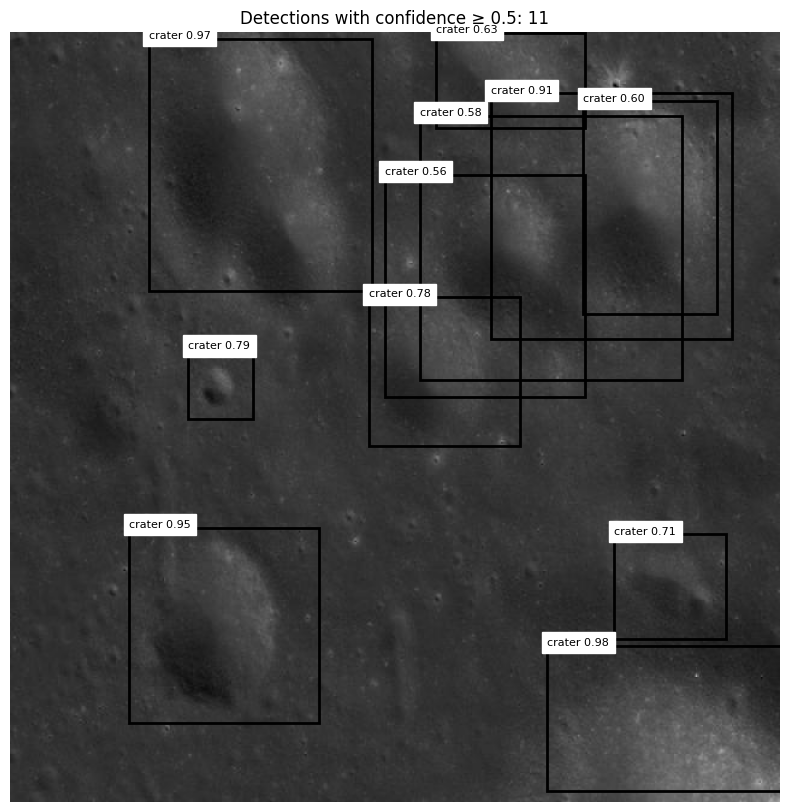

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Confidence threshold
threshold = 0.5

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image)

boxes = prediction["boxes"].cpu()
scores = prediction["scores"].cpu()
labels = prediction["labels"].cpu()

count = 0

for box, score, label in zip(boxes, scores, labels):
    if score >= threshold:
        x1, y1, x2, y2 = box.tolist()

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            f"crater {score:.2f}",
            fontsize=8,
            backgroundcolor="white"
        )

        count += 1

ax.axis("off")
plt.title(f"Detections with confidence ≥ {threshold}: {count}")
plt.show()

In [19]:
import json
import os

# Load COCO annotations
ann_path = "/content/lunar_data/test/_annotations.coco.json"

with open(ann_path, "r") as f:
    coco = json.load(f)

# Find annotation entry for our image
image_filename = os.path.basename(image_path)

image_info = next(
    img for img in coco["images"]
    if img["file_name"] == image_filename
)

image_id = image_info["id"]

# Get ground-truth annotations
gt_annotations = [
    ann for ann in coco["annotations"]
    if ann["image_id"] == image_id
]

print("Image:", image_filename)
print("Ground-truth craters:", len(gt_annotations))

for ann in gt_annotations:
    print("bbox:", ann["bbox"])

Image: ch2_tmc_ncn_20220719T0152362943_b_brw_d1814_jpeg.rf.c40bed95c180e2e4553c12c2261c3a7a.jpg
Ground-truth craters: 8
bbox: [421, 47, 174, 172.5]
bbox: [113, 16, 177.5, 219.5]
bbox: [98, 418, 136, 166.5]
bbox: [474, 531, 160, 108.5]
bbox: [514, 428, 84, 62.5]
bbox: [140, 266, 54.5, 45.5]
bbox: [283, 251, 131.5, 88.5]
bbox: [349, 0, 97, 93.5]


In [20]:
import torch

def calculate_iou(box1, box2):
    # box format: [x1, y1, x2, y2]

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


# Convert COCO [x, y, width, height]
# to [x1, y1, x2, y2]

gt_boxes = []

for ann in gt_annotations:
    x, y, w, h = ann["bbox"]
    gt_boxes.append([x, y, x + w, y + h])


# Keep predictions >= 0.5
pred_boxes = []
pred_scores = []

for box, score in zip(
    prediction["boxes"].cpu().tolist(),
    prediction["scores"].cpu().tolist()
):
    if score >= 0.5:
        pred_boxes.append(box)
        pred_scores.append(score)


# Compare every prediction against best ground truth
print("GROUND TRUTH:", len(gt_boxes))
print("PREDICTIONS:", len(pred_boxes))
print()

for i, (pred_box, score) in enumerate(zip(pred_boxes, pred_scores)):

    best_iou = 0
    best_gt = -1

    for j, gt_box in enumerate(gt_boxes):

        iou = calculate_iou(pred_box, gt_box)

        if iou > best_iou:
            best_iou = iou
            best_gt = j

    status = "MATCH" if best_iou >= 0.5 else "FALSE POSITIVE"

    print(
        f"Prediction {i+1:2d} | "
        f"confidence={score:.3f} | "
        f"best IoU={best_iou:.3f} | "
        f"GT={best_gt} | "
        f"{status}"
    )

GROUND TRUTH: 8
PREDICTIONS: 11

Prediction  1 | confidence=0.981 | best IoU=0.641 | GT=3 | MATCH
Prediction  2 | confidence=0.967 | best IoU=0.811 | GT=1 | MATCH
Prediction  3 | confidence=0.953 | best IoU=0.780 | GT=2 | MATCH
Prediction  4 | confidence=0.909 | best IoU=0.709 | GT=0 | MATCH
Prediction  5 | confidence=0.791 | best IoU=0.611 | GT=5 | MATCH
Prediction  6 | confidence=0.779 | best IoU=0.613 | GT=6 | MATCH
Prediction  7 | confidence=0.709 | best IoU=0.608 | GT=4 | MATCH
Prediction  8 | confidence=0.632 | best IoU=0.636 | GT=7 | MATCH
Prediction  9 | confidence=0.596 | best IoU=0.571 | GT=0 | MATCH
Prediction 10 | confidence=0.583 | best IoU=0.360 | GT=0 | FALSE POSITIVE
Prediction 11 | confidence=0.562 | best IoU=0.145 | GT=6 | FALSE POSITIVE


In [1]:
import torch

print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU: True
Device: Tesla T4


In [2]:
print("model exists:", "model" in globals())
print("test_images exists:", "test_images" in globals())

model exists: False
test_images exists: False


In [3]:
import os

print("Lunar data:", os.path.exists("/content/lunar_data"))
print("Model file:", os.path.exists("/content/trained_model.pth"))

print("\n/content files:")
print(os.listdir("/content")[:20])

Lunar data: False
Model file: False

/content files:
['.config', 'sample_data']


In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [5]:
from google.colab import files

uploaded = files.upload()

Saving lunar.v3i.coco.zip to lunar.v3i.coco.zip


In [6]:
!ls -lh

total 69M
-rw-r--r-- 1 root root  69M Aug 29 05:51 lunar.v3i.coco.zip
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data


In [7]:
from google.colab import files

uploaded = files.upload()


Saving trained_model.pth to trained_model.pth


In [8]:
!ls -lh

total 142M
-rw-r--r-- 1 root root  69M Aug 29 05:51 lunar.v3i.coco.zip
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data
-rw-r--r-- 1 root root  73M Aug 29 05:59 trained_model.pth


In [9]:
!rm -rf /content/lunar_data
!unzip -q "/content/lunar.v3i.coco.zip" -d /content/lunar_data

In [10]:
!find /content/lunar_data -maxdepth 2 -type f | head -20

/content/lunar_data/test/ch2_tmc_ncn_20220121T1658022047_b_brw_d1868_jpeg.rf.1af8969a6b0bad00a613ab32a6c784a9.jpg
/content/lunar_data/test/ch2_tmc_ncn_20221118T2208306167_b_brw_d3224_jpeg.rf.4561927b13dd215d9ad03399499d7e7f.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220101T0110303578_b_brw_d1832_jpeg.rf.aa5f8213f6d19efc912bf7255b4b35bf.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220624T0620248788_b_brw_d3211_jpeg.rf.8c2a7c189d2d5184107bb5ce649c940e.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220604T0546183777_b_brw_d3261_jpeg.rf.58ae072bad289ce72abe04ad19445154.jpg
/content/lunar_data/test/ch2_tmc_ncn_20221123T0839171051_b_brw_d3218_jpeg.rf.3baf0b013adc81b28d86caf4f3309f5d.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220111T1721503392_b_brw_d3226_jpeg.rf.7c2318b6832cd81280573a8f6c1b2c00.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220109T1615439830_b_brw_d3267_jpeg.rf.64e73a9ea0fc62f890711b5cf3d49a3d.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220730T1023574780_b_brw_d3247_jpeg.rf.38baa8fff0a

In [11]:
import os
import glob

for split in ["train", "valid", "test"]:
    images = glob.glob(f"/content/lunar_data/{split}/*.jpg")
    jsons = glob.glob(f"/content/lunar_data/{split}/*.json")

    print(f"\n{'='*50}")
    print(f"{split.upper()}")
    print(f"Images: {len(images)}")
    print(f"JSON files: {jsons}")


TRAIN
Images: 1293
JSON files: ['/content/lunar_data/train/_annotations.coco.json']

VALID
Images: 371
JSON files: ['/content/lunar_data/valid/_annotations.coco.json']

TEST
Images: 184
JSON files: ['/content/lunar_data/test/_annotations.coco.json']


In [12]:
import torch
import os

MODEL_PATH = "/content/trained_model.pth"

print("File exists:", os.path.exists(MODEL_PATH))
print("Size:", os.path.getsize(MODEL_PATH) / (1024**2), "MB")

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print(" ", k)

File exists: True
Size: 72.4987735748291 MB
Checkpoint type: <class 'collections.OrderedDict'>

Checkpoint keys:
  backbone.body.0.0.weight
  backbone.body.0.1.weight
  backbone.body.0.1.bias
  backbone.body.0.1.running_mean
  backbone.body.0.1.running_var
  backbone.body.1.block.0.0.weight
  backbone.body.1.block.0.1.weight
  backbone.body.1.block.0.1.bias
  backbone.body.1.block.0.1.running_mean
  backbone.body.1.block.0.1.running_var
  backbone.body.1.block.1.0.weight
  backbone.body.1.block.1.1.weight
  backbone.body.1.block.1.1.bias
  backbone.body.1.block.1.1.running_mean
  backbone.body.1.block.1.1.running_var
  backbone.body.2.block.0.0.weight
  backbone.body.2.block.0.1.weight
  backbone.body.2.block.0.1.bias
  backbone.body.2.block.0.1.running_mean
  backbone.body.2.block.0.1.running_var
  backbone.body.2.block.1.0.weight
  backbone.body.2.block.1.1.weight
  backbone.body.2.block.1.1.bias
  backbone.body.2.block.1.1.running_mean
  backbone.body.2.block.1.1.running_var
  backb

In [13]:
import os
import zipfile

zip_path = "/content/lunar.v3i.coco.zip"
extract_path = "/content/lunar_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print(os.listdir(extract_path))

Extracted successfully!
['test', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'valid']


In [14]:
!find /content/lunar_data -maxdepth 2 -type f | head -20

/content/lunar_data/test/ch2_tmc_ncn_20220121T1658022047_b_brw_d1868_jpeg.rf.1af8969a6b0bad00a613ab32a6c784a9.jpg
/content/lunar_data/test/ch2_tmc_ncn_20221118T2208306167_b_brw_d3224_jpeg.rf.4561927b13dd215d9ad03399499d7e7f.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220101T0110303578_b_brw_d1832_jpeg.rf.aa5f8213f6d19efc912bf7255b4b35bf.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220624T0620248788_b_brw_d3211_jpeg.rf.8c2a7c189d2d5184107bb5ce649c940e.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220604T0546183777_b_brw_d3261_jpeg.rf.58ae072bad289ce72abe04ad19445154.jpg
/content/lunar_data/test/ch2_tmc_ncn_20221123T0839171051_b_brw_d3218_jpeg.rf.3baf0b013adc81b28d86caf4f3309f5d.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220111T1721503392_b_brw_d3226_jpeg.rf.7c2318b6832cd81280573a8f6c1b2c00.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220109T1615439830_b_brw_d3267_jpeg.rf.64e73a9ea0fc62f890711b5cf3d49a3d.jpg
/content/lunar_data/test/ch2_tmc_ncn_20220730T1023574780_b_brw_d3247_jpeg.rf.38baa8fff0a

In [15]:
import os

for split in ["train", "valid", "test"]:
    path = f"/content/lunar_data/{split}"
    images = [
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{split.upper()}: {len(images)} images")
    print("JSON:", os.path.exists(f"{path}/_annotations.coco.json"))
    print()

print("MODEL:", os.path.exists("/content/trained_model.pth"))

TRAIN: 1293 images
JSON: True

VALID: 371 images
JSON: True

TEST: 184 images
JSON: True

MODEL: True


In [15]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


class LunarDataset(Dataset):

    def __init__(self, root):
        self.root = root

        with open(os.path.join(root, "_annotations.coco.json"), "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]

        # image_id -> annotations
        self.annotations = {}
        for ann in self.coco["annotations"]:
            self.annotations.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_info = self.images[idx]

        image_path = os.path.join(
            self.root,
            img_info["file_name"]
        )

        image = Image.open(image_path).convert("RGB")

        image = torchvision.transforms.functional.to_tensor(image)

        anns = self.annotations.get(img_info["id"], [])

        boxes = []
        labels = []

        for ann in anns:

            x, y, w, h = ann["bbox"]

            # COCO:
            # x, y, width, height
            #
            # Faster R-CNN:
            # x1, y1, x2, y2

            if w <= 0 or h <= 0:
                continue

            boxes.append([
                x,
                y,
                x + w,
                y + h
            ])

            # Your dataset's only actual object class = crater
            labels.append(1)

        boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)

        labels = torch.tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_info["id"]])
        }

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = LunarDataset(
    "/content/lunar_data/train"
)

valid_dataset = LunarDataset(
    "/content/lunar_data/valid"
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("✅ Dataset loaders ready")

Using: cuda
GPU: Tesla T4


FileNotFoundError: [Errno 2] No such file or directory: '/content/lunar_data/train/_annotations.coco.json'

In [16]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

MODEL_PATH = "/content/trained_model.pth"

# Exact architecture used by the previous team
model = fasterrcnn_mobilenet_v3_large_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

# Load their trained weights
checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

# Handle either a raw state_dict or a checkpoint dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

# Remove possible "module." prefix if present
state_dict = {
    k.replace("module.", "", 1): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict, strict=True)

model = model.to(device)

print("✅ Model loaded")
print("Device:", next(model.parameters()).device)

print(
    "Classifier:",
    model.roi_heads.box_predictor.cls_score.weight.shape
)

print(
    "BBox predictor:",
    model.roi_heads.box_predictor.bbox_pred.weight.shape
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/trained_model.pth'

In [17]:
from google.colab import files

uploaded = files.upload()

Saving lunar.v3i.coco.zip to lunar.v3i.coco.zip


In [18]:
import os
import glob
import json
import torch
from PIL import Image
import torchvision.transforms.functional as TF

model.eval()

TEST_DIR = "/content/lunar_data/test"
ANN_FILE = os.path.join(TEST_DIR, "_annotations.coco.json")

# Load COCO annotations
with open(ANN_FILE, "r") as f:
    coco = json.load(f)

# Map image ID -> annotations
annotations_by_image = {}

for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

# Map filename -> image information
images_by_filename = {
    img["file_name"]: img
    for img in coco["images"]
}

test_images = glob.glob(
    os.path.join(TEST_DIR, "*.jpg")
)

print("Test images:", len(test_images))
print("Annotated images:", len(images_by_filename))

Test images: 184
Annotated images: 184


In [19]:
# Baseline evaluation settings
CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

total_tp = 0
total_fp = 0
total_fn = 0

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    intersection = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


model.eval()

for i, image_path in enumerate(test_images):

    filename = os.path.basename(image_path)
    image_info = images_by_filename[filename]
    image_id = image_info["id"]

    # Ground-truth boxes
    gt_boxes = []

    for ann in annotations_by_image.get(image_id, []):
        x, y, w, h = ann["bbox"]

        if w > 0 and h > 0:
            gt_boxes.append([
                x,
                y,
                x + w,
                y + h
            ])

    # Load image
    image = Image.open(image_path).convert("RGB")
    image_tensor = TF.to_tensor(image).to(device)

    # Model prediction
    with torch.no_grad():
        prediction = model([image_tensor])[0]

    # Confidence filtering
    predictions = []

    for box, score in zip(
        prediction["boxes"].cpu().tolist(),
        prediction["scores"].cpu().tolist()
    ):
        if score >= CONF_THRESHOLD:
            predictions.append((box, score))

    # Highest confidence first
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    matched_gt = set()

    # Greedy one-to-one matching
    for pred_box, score in predictions:

        best_iou = 0
        best_gt_idx = None

        for gt_idx, gt_box in enumerate(gt_boxes):

            if gt_idx in matched_gt:
                continue

            iou = calculate_iou(pred_box, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= IOU_THRESHOLD:
            total_tp += 1
            matched_gt.add(best_gt_idx)
        else:
            total_fp += 1

    # Anything not matched = missed detection
    total_fn += len(gt_boxes) - len(matched_gt)

    if (i + 1) % 20 == 0:
        print(f"Processed {i + 1}/{len(test_images)}")

# Metrics
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

print("\n" + "=" * 55)
print("OLD MODEL BASELINE")
print("=" * 55)
print(f"True Positives : {total_tp}")
print(f"False Positives: {total_fp}")
print(f"False Negatives: {total_fn}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print("=" * 55)

Processed 20/184
Processed 40/184
Processed 60/184
Processed 80/184
Processed 100/184
Processed 120/184
Processed 140/184
Processed 160/184
Processed 180/184

OLD MODEL BASELINE
True Positives : 349
False Positives: 660
False Negatives: 1197
Precision      : 0.3459
Recall         : 0.2257
F1 Score       : 0.2732


In [20]:
# Test how confidence threshold affects the OLD model

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

model.eval()

for CONF_THRESHOLD in thresholds:

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for image_path in test_images:

        filename = os.path.basename(image_path)
        image_info = images_by_filename[filename]
        image_id = image_info["id"]

        # Ground truth
        gt_boxes = []

        for ann in annotations_by_image.get(image_id, []):
            x, y, w, h = ann["bbox"]

            if w > 0 and h > 0:
                gt_boxes.append([
                    x, y,
                    x + w,
                    y + h
                ])

        # Image
        image = Image.open(image_path).convert("RGB")
        image_tensor = TF.to_tensor(image).to(device)

        # Prediction
        with torch.no_grad():
            prediction = model([image_tensor])[0]

        predictions = []

        for box, score in zip(
            prediction["boxes"].cpu().tolist(),
            prediction["scores"].cpu().tolist()
        ):
            if score >= CONF_THRESHOLD:
                predictions.append((box, score))

        predictions.sort(
            key=lambda x: x[1],
            reverse=True
        )

        matched_gt = set()

        for pred_box, score in predictions:

            best_iou = 0
            best_gt_idx = None

            for gt_idx, gt_box in enumerate(gt_boxes):

                if gt_idx in matched_gt:
                    continue

                iou = calculate_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_iou >= IOU_THRESHOLD:
                total_tp += 1
                matched_gt.add(best_gt_idx)
            else:
                total_fp += 1

        total_fn += len(gt_boxes) - len(matched_gt)

    precision = (
        total_tp / (total_tp + total_fp)
        if total_tp + total_fp else 0
    )

    recall = (
        total_tp / (total_tp + total_fn)
        if total_tp + total_fn else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0
    )

    print(
        f"Threshold {CONF_THRESHOLD:.1f} | "
        f"TP={total_tp} | "
        f"FP={total_fp} | "
        f"FN={total_fn} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold 0.1 | TP=819 | FP=10893 | FN=727 | Precision=0.070 | Recall=0.530 | F1=0.124
Threshold 0.2 | TP=619 | FP=4200 | FN=927 | Precision=0.128 | Recall=0.400 | F1=0.195
Threshold 0.3 | TP=513 | FP=2102 | FN=1033 | Precision=0.196 | Recall=0.332 | F1=0.247
Threshold 0.4 | TP=422 | FP=1135 | FN=1124 | Precision=0.271 | Recall=0.273 | F1=0.272
Threshold 0.5 | TP=349 | FP=660 | FN=1197 | Precision=0.346 | Recall=0.226 | F1=0.273


In [21]:
import torch
import os
import time

# -----------------------------
# Training settings
# -----------------------------
NUM_EPOCHS = 20
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Make sure model is in training mode
model.train()

# Faster R-CNN uses SGD commonly
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# Reduce learning rate during training
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

print("Training setup ready")
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Checkpoint directory:", CHECKPOINT_DIR)

Training setup ready
Epochs: 20
Learning rate: 0.005
Checkpoint directory: /content/checkpoints


In [25]:
best_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    model.train()

    epoch_loss = 0.0
    start_time = time.time()

    for batch_idx, (images, targets) in enumerate(train_loader):

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        # Forward + loss
        loss_dict = model(
            images,
            targets
        )

        losses = sum(
            loss for loss in loss_dict.values()
        )

        # Backprop
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                f"Batch {batch_idx+1}/{len(train_loader)} | "
                f"Loss: {losses.item():.4f}"
            )

    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed = time.time() - start_time

    print("\n" + "=" * 60)
    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} COMPLETE"
    )
    print(
        f"Average loss: {avg_loss:.4f}"
    )
    print(
        f"Time: {elapsed:.1f} sec"
    )
    print(
        f"Learning rate: {optimizer.param_groups[0]['lr']}"
    )
    print("=" * 60)

    # Save EVERY epoch
    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"epoch_{epoch+1}.pth"
    )

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss
        },
        checkpoint_path
    )

    # Track best training loss
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                CHECKPOINT_DIR,
                "best_model.pth"
            )
        )

        print(
            f"⭐ New best model! "
            f"Loss = {best_loss:.4f}"
        )

    print()

Epoch 1/20 | Batch 50/324 | Loss: 0.7054
Epoch 1/20 | Batch 100/324 | Loss: 1.5376
Epoch 1/20 | Batch 150/324 | Loss: 1.0407
Epoch 1/20 | Batch 200/324 | Loss: 0.8800
Epoch 1/20 | Batch 250/324 | Loss: 0.8459
Epoch 1/20 | Batch 300/324 | Loss: 1.0793

Epoch 1/20 COMPLETE
Average loss: 1.1126
Time: 87.6 sec
Learning rate: 0.005
⭐ New best model! Loss = 1.1126

Epoch 2/20 | Batch 50/324 | Loss: 0.9813
Epoch 2/20 | Batch 100/324 | Loss: 1.1389
Epoch 2/20 | Batch 150/324 | Loss: 1.0469
Epoch 2/20 | Batch 200/324 | Loss: 1.1549
Epoch 2/20 | Batch 250/324 | Loss: 0.9923
Epoch 2/20 | Batch 300/324 | Loss: 1.1530

Epoch 2/20 COMPLETE
Average loss: 1.0737
Time: 90.5 sec
Learning rate: 0.005
⭐ New best model! Loss = 1.0737

Epoch 3/20 | Batch 50/324 | Loss: 0.5278
Epoch 3/20 | Batch 100/324 | Loss: 0.7660
Epoch 3/20 | Batch 150/324 | Loss: 0.9028
Epoch 3/20 | Batch 200/324 | Loss: 0.9915
Epoch 3/20 | Batch 250/324 | Loss: 1.2429
Epoch 3/20 | Batch 300/324 | Loss: 0.5828

Epoch 3/20 COMPLETE
Aver

In [24]:
for images, targets in train_loader:
    for t in targets:
        assert t["boxes"].shape[1] == 4

print("✅ Training loader passed")

✅ Training loader passed


In [26]:
!ls -lh /content/*.pth

-rw-r--r-- 1 root root 73M Aug 29 05:59 /content/trained_model.pth


In [27]:
!find /content -name "*.pth" -type f

/content/trained_model.pth
/content/checkpoints/epoch_12.pth
/content/checkpoints/epoch_11.pth
/content/checkpoints/epoch_6.pth
/content/checkpoints/epoch_18.pth
/content/checkpoints/best_model.pth
/content/checkpoints/epoch_4.pth
/content/checkpoints/epoch_2.pth
/content/checkpoints/epoch_8.pth
/content/checkpoints/epoch_14.pth
/content/checkpoints/epoch_19.pth
/content/checkpoints/epoch_9.pth
/content/checkpoints/epoch_1.pth
/content/checkpoints/epoch_17.pth
/content/checkpoints/epoch_7.pth
/content/checkpoints/epoch_16.pth
/content/checkpoints/epoch_20.pth
/content/checkpoints/epoch_3.pth
/content/checkpoints/epoch_15.pth
/content/checkpoints/epoch_13.pth
/content/checkpoints/epoch_10.pth
/content/checkpoints/epoch_5.pth


In [28]:
checkpoint = torch.load(
    "/content/checkpoints/best_model.pth",
    map_location=device
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

Checkpoint type: <class 'collections.OrderedDict'>
Checkpoint keys: odict_keys(['backbone.body.0.0.weight', 'backbone.body.0.1.weight', 'backbone.body.0.1.bias', 'backbone.body.0.1.running_mean', 'backbone.body.0.1.running_var', 'backbone.body.0.1.num_batches_tracked', 'backbone.body.1.block.0.0.weight', 'backbone.body.1.block.0.1.weight', 'backbone.body.1.block.0.1.bias', 'backbone.body.1.block.0.1.running_mean', 'backbone.body.1.block.0.1.running_var', 'backbone.body.1.block.0.1.num_batches_tracked', 'backbone.body.1.block.1.0.weight', 'backbone.body.1.block.1.1.weight', 'backbone.body.1.block.1.1.bias', 'backbone.body.1.block.1.1.running_mean', 'backbone.body.1.block.1.1.running_var', 'backbone.body.1.block.1.1.num_batches_tracked', 'backbone.body.2.block.0.0.weight', 'backbone.body.2.block.0.1.weight', 'backbone.body.2.block.0.1.bias', 'backbone.body.2.block.0.1.running_mean', 'backbone.body.2.block.0.1.running_var', 'backbone.body.2.block.0.1.num_batches_tracked', 'backbone.body.2

In [29]:
# Load the BEST checkpoint
best_checkpoint = torch.load(
    "/content/checkpoints/best_model.pth",
    map_location=device
)

print("Checkpoint type:", type(best_checkpoint))
print("Number of parameters:", len(best_checkpoint))
print("First 5 keys:")
for key in list(best_checkpoint.keys())[:5]:
    print(" ", key)

Checkpoint type: <class 'collections.OrderedDict'>
Number of parameters: 330
First 5 keys:
  backbone.body.0.0.weight
  backbone.body.0.1.weight
  backbone.body.0.1.bias
  backbone.body.0.1.running_mean
  backbone.body.0.1.running_var


In [30]:
import torchvision

# Build the same architecture
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

# Load our best trained checkpoint
checkpoint = torch.load(
    "/content/checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("✅ BEST MODEL LOADED")
print("Device:", device)
print("Classes: background + crater")

✅ BEST MODEL LOADED
Device: cuda
Classes: background + crater


In [33]:
from torchvision.ops import box_iou
from PIL import Image
import torch
import os

def calculate_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


# --------------------------------------------------
# EVALUATION
# --------------------------------------------------

model.eval()

TP = 0
FP = 0
FN = 0

IOU_THRESHOLD = 0.5
CONFIDENCE_THRESHOLD = 0.5

test_images = test_dataset

print("Evaluating BEST MODEL...")
print("Test images:", len(test_images))

for idx in range(len(test_images)):

    image, target = test_images[idx]

    # Move image to GPU
    image_gpu = image.to(device)

    # Prediction
    with torch.no_grad():
        prediction = model([image_gpu])[0]

    pred_boxes = prediction["boxes"].detach().cpu()
    pred_scores = prediction["scores"].detach().cpu()

    # Keep predictions above confidence threshold
    keep = pred_scores >= CONFIDENCE_THRESHOLD

    pred_boxes = pred_boxes[keep]

    gt_boxes = target["boxes"]

    # Track which GT boxes have already been matched
    matched_gt = set()

    # Match each prediction to the best unused GT
    for pred_box in pred_boxes:

        best_iou = 0
        best_gt = -1

        for j, gt_box in enumerate(gt_boxes):

            if j in matched_gt:
                continue

            iou = calculate_iou(
                pred_box.tolist(),
                gt_box.tolist()
            )

            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= IOU_THRESHOLD:
            TP += 1
            matched_gt.add(best_gt)
        else:
            FP += 1

    # Any unmatched GT = false negative
    FN += len(gt_boxes) - len(matched_gt)

    if (idx + 1) % 20 == 0:
        print(f"Processed {idx + 1}/{len(test_images)}")


# --------------------------------------------------
# METRICS
# --------------------------------------------------

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print()
print("=" * 55)
print("NEW MODEL RESULTS")
print("=" * 55)
print("True Positives :", TP)
print("False Positives:", FP)
print("False Negatives:", FN)
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print("=" * 55)

print()
print("OLD MODEL BASELINE")
print("Precision = 0.3459")
print("Recall    = 0.2257")
print("F1        = 0.2732")

Evaluating BEST MODEL...
Test images: 184
Processed 20/184
Processed 40/184
Processed 60/184
Processed 80/184
Processed 100/184
Processed 120/184
Processed 140/184
Processed 160/184
Processed 180/184

NEW MODEL RESULTS
True Positives : 369
False Positives: 1032
False Negatives: 1177
Precision      : 0.2634
Recall         : 0.2387
F1 Score       : 0.2504

OLD MODEL BASELINE
Precision = 0.3459
Recall    = 0.2257
F1        = 0.2732


In [32]:
test_dataset = LunarDataset("/content/lunar_data/test")

print("Test dataset:", len(test_dataset))

Test dataset: 184


In [34]:
# Threshold sweep for the NEW/BEST model

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for CONFIDENCE_THRESHOLD in thresholds:

    TP = 0
    FP = 0
    FN = 0

    for idx in range(len(test_dataset)):

        image, target = test_dataset[idx]
        image_gpu = image.to(device)

        with torch.no_grad():
            prediction = model([image_gpu])[0]

        pred_boxes = prediction["boxes"].detach().cpu()
        pred_scores = prediction["scores"].detach().cpu()

        keep = pred_scores >= CONFIDENCE_THRESHOLD
        pred_boxes = pred_boxes[keep]

        gt_boxes = target["boxes"]
        matched_gt = set()

        for pred_box in pred_boxes:

            best_iou = 0
            best_gt = -1

            for j, gt_box in enumerate(gt_boxes):

                if j in matched_gt:
                    continue

                iou = calculate_iou(
                    pred_box.tolist(),
                    gt_box.tolist()
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= 0.5:
                TP += 1
                matched_gt.add(best_gt)
            else:
                FP += 1

        FN += len(gt_boxes) - len(matched_gt)

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0
    )

    print(
        f"Threshold {CONFIDENCE_THRESHOLD:.2f} | "
        f"TP={TP} | FP={FP} | FN={FN} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold 0.30 | TP=466 | FP=1993 | FN=1080 | Precision=0.190 | Recall=0.301 | F1=0.233
Threshold 0.35 | TP=441 | FP=1672 | FN=1105 | Precision=0.209 | Recall=0.285 | F1=0.241
Threshold 0.40 | TP=422 | FP=1389 | FN=1124 | Precision=0.233 | Recall=0.273 | F1=0.251
Threshold 0.45 | TP=395 | FP=1193 | FN=1151 | Precision=0.249 | Recall=0.255 | F1=0.252
Threshold 0.50 | TP=369 | FP=1032 | FN=1177 | Precision=0.263 | Recall=0.239 | F1=0.250
Threshold 0.55 | TP=340 | FP=888 | FN=1206 | Precision=0.277 | Recall=0.220 | F1=0.245
Threshold 0.60 | TP=321 | FP=748 | FN=1225 | Precision=0.300 | Recall=0.208 | F1=0.246
Threshold 0.65 | TP=296 | FP=634 | FN=1250 | Precision=0.318 | Recall=0.191 | F1=0.239
Threshold 0.70 | TP=270 | FP=533 | FN=1276 | Precision=0.336 | Recall=0.175 | F1=0.230


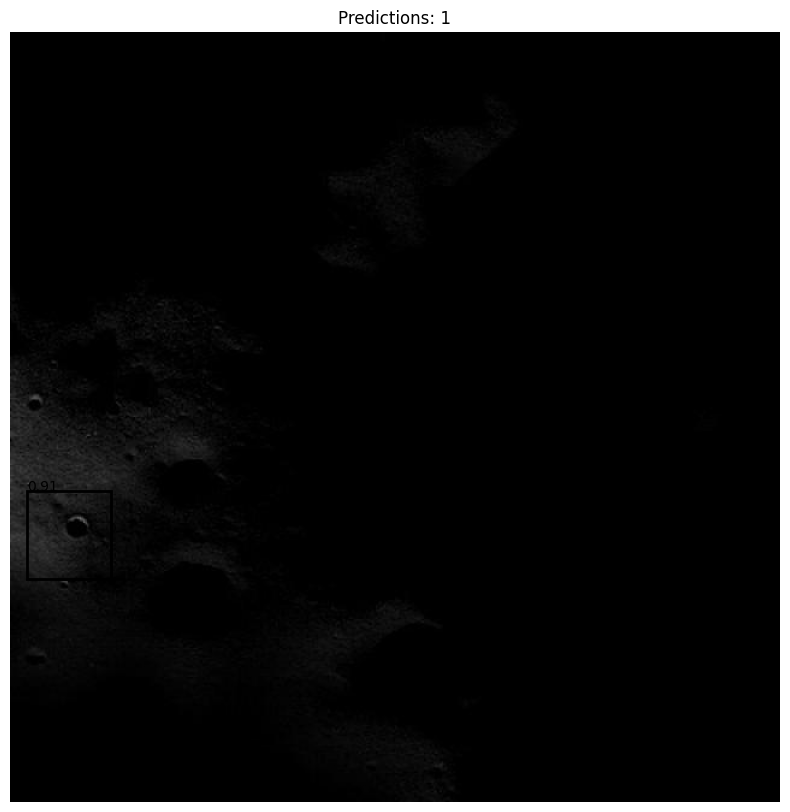

In [35]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# Pick a test image
idx = 0

image, target = test_dataset[idx]

with torch.no_grad():
    prediction = model([image.to(device)])[0]

# Move everything to CPU
img = image.permute(1, 2, 0).numpy()

boxes = prediction["boxes"].cpu()
scores = prediction["scores"].cpu()

# Show only reasonably confident detections
threshold = 0.45
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]

plt.figure(figsize=(10, 10))
plt.imshow(img)

for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = box.tolist()

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(rect)

    plt.text(
        x1,
        y1,
        f"{score:.2f}"
    )

plt.axis("off")
plt.title(f"Predictions: {len(boxes)}")
plt.show()

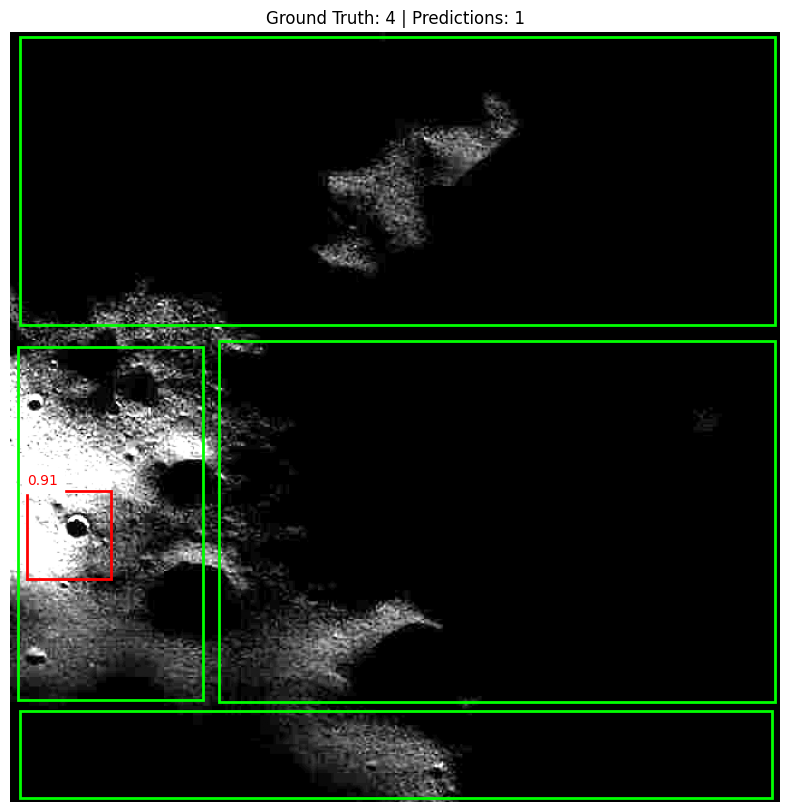

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

idx = 0

image, target = test_dataset[idx]

with torch.no_grad():
    prediction = model([image.to(device)])[0]

img = image.permute(1, 2, 0).numpy()

# Convert to grayscale for better visualization
gray = img.mean(axis=2)

# Contrast enhancement ONLY for visualization
low, high = np.percentile(gray, [2, 98])
display_img = np.clip((gray - low) / (high - low + 1e-8), 0, 1)

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(display_img, cmap="gray")

# -------------------------
# GROUND TRUTH
# -------------------------
for box in target["boxes"]:
    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
        edgecolor="lime"
    )

    ax.add_patch(rect)

# -------------------------
# PREDICTIONS
# -------------------------
threshold = 0.45

boxes = prediction["boxes"].cpu()
scores = prediction["scores"].cpu()

keep = scores >= threshold

for box, score in zip(boxes[keep], scores[keep]):

    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
        edgecolor="red"
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        max(0, y1 - 5),
        f"{score:.2f}",
        color="red",
        fontsize=10,
        backgroundcolor="white"
    )

ax.set_title(
    f"Ground Truth: {len(target['boxes'])} | "
    f"Predictions: {keep.sum().item()}"
)

ax.axis("off")
plt.show()

In [37]:
idx = 0

image, target = test_dataset[idx]

print("Image:", test_dataset.images[idx]["file_name"])
print("Number of GT boxes:", len(target["boxes"]))

for i, box in enumerate(target["boxes"]):
    x1, y1, x2, y2 = box.tolist()

    print(
        f"GT {i}: "
        f"x1={x1:.1f}, y1={y1:.1f}, "
        f"x2={x2:.1f}, y2={y2:.1f}, "
        f"width={x2-x1:.1f}, height={y2-y1:.1f}"
    )

Image: ch2_tmc_ncn_20220111T1128205233_b_brw_d3217_jpeg.rf.1378bd2c8e945674b5af2818d9adcf21.jpg
Number of GT boxes: 4
GT 0: x1=6.0, y1=261.0, x2=160.0, y2=554.5, width=154.0, height=293.5
GT 1: x1=8.0, y1=4.0, x2=635.0, y2=243.0, width=627.0, height=239.0
GT 2: x1=173.0, y1=256.0, x2=635.0, y2=556.5, width=462.0, height=300.5
GT 3: x1=8.0, y1=564.0, x2=633.0, y2=636.5, width=625.0, height=72.5


In [38]:
img_id = test_dataset.images[0]["id"]

for ann in test_dataset.coco["annotations"]:
    if ann["image_id"] == img_id:
        print("\nAnnotation:")
        print("category_id:", ann["category_id"])
        print("bbox:", ann["bbox"])
        print("area:", ann.get("area"))
        print("iscrowd:", ann.get("iscrowd"))
        print("segmentation type:", type(ann.get("segmentation")))
        print("segmentation:", ann.get("segmentation"))


Annotation:
category_id: 1
bbox: [6, 261, 154, 293.5]
area: 45199
iscrowd: 0
segmentation type: <class 'list'>
segmentation: []

Annotation:
category_id: 1
bbox: [8, 4, 627, 239]
area: 149853
iscrowd: 0
segmentation type: <class 'list'>
segmentation: []

Annotation:
category_id: 1
bbox: [173, 256, 462, 300.5]
area: 138831
iscrowd: 0
segmentation type: <class 'list'>
segmentation: []

Annotation:
category_id: 1
bbox: [8, 564, 625, 72.5]
area: 45312.5
iscrowd: 0
segmentation type: <class 'list'>
segmentation: []


In [39]:
# Analyze how large the annotations are relative to the 640x640 images

import numpy as np

widths = []
heights = []
areas = []
area_ratios = []

for ann in test_dataset.coco["annotations"]:

    x, y, w, h = ann["bbox"]

    widths.append(w)
    heights.append(h)
    areas.append(w * h)
    area_ratios.append((w * h) / (640 * 640))

print("Total annotations:", len(areas))

print("\nAverage:")
print("Width :", round(np.mean(widths), 2))
print("Height:", round(np.mean(heights), 2))
print("Area ratio:", round(np.mean(area_ratios) * 100, 2), "%")

print("\nMedian:")
print("Width :", round(np.median(widths), 2))
print("Height:", round(np.median(heights), 2))
print("Area ratio:", round(np.median(area_ratios) * 100, 2), "%")

print("\nLargest 10 boxes by image area:")

for i in np.argsort(area_ratios)[-10:][::-1]:
    print(
        f"{area_ratios[i]*100:.1f}% of image | "
        f"{widths[i]:.1f} x {heights[i]:.1f}"
    )

Total annotations: 1546

Average:
Width : 94.78
Height: 96.92
Area ratio: 3.22 %

Median:
Width : 71.0
Height: 74.25
Area ratio: 1.29 %

Largest 10 boxes by image area:
76.5% of image | 638.0 x 491.0
70.2% of image | 635.0 x 453.0
54.3% of image | 465.5 x 478.0
47.8% of image | 432.0 x 453.0
43.7% of image | 405.0 x 442.0
39.2% of image | 445.0 x 361.0
37.7% of image | 419.0 x 369.0
36.6% of image | 627.0 x 239.0
33.9% of image | 462.0 x 300.5
32.2% of image | 372.5 x 354.5


In [40]:
# Count suspiciously large annotations

thresholds = [0.05, 0.10, 0.20, 0.30]

for threshold in thresholds:
    count = sum(
        ((ann["bbox"][2] * ann["bbox"][3]) / (640 * 640)) > threshold
        for ann in test_dataset.coco["annotations"]
    )

    print(
        f"> {threshold*100:.0f}% of image: "
        f"{count} annotations"
    )

> 5% of image: 294 annotations
> 10% of image: 100 annotations
> 20% of image: 28 annotations
> 30% of image: 12 annotations


In [41]:
# Show the actual suspicious annotations

for ann in test_dataset.coco["annotations"]:

    x, y, w, h = ann["bbox"]
    ratio = (w * h) / (640 * 640)

    if ratio > 0.20:
        print(
            f"Image ID: {ann['image_id']} | "
            f"bbox: {ann['bbox']} | "
            f"coverage: {ratio*100:.1f}%"
        )

Image ID: 0 | bbox: [8, 4, 627, 239] | coverage: 36.6%
Image ID: 0 | bbox: [173, 256, 462, 300.5] | coverage: 33.9%
Image ID: 4 | bbox: [7, 271, 419, 369] | coverage: 37.7%
Image ID: 8 | bbox: [276, 327, 364, 303] | coverage: 26.9%
Image ID: 9 | bbox: [0, 0, 445, 361] | coverage: 39.2%
Image ID: 13 | bbox: [0, 0, 432, 453] | coverage: 47.8%
Image ID: 15 | bbox: [324, 143, 285, 319] | coverage: 22.2%
Image ID: 24 | bbox: [272, 336, 313.5, 304] | coverage: 23.3%
Image ID: 34 | bbox: [122, 196, 316, 411] | coverage: 31.7%
Image ID: 41 | bbox: [15, 10, 158.5, 594.5] | coverage: 23.0%
Image ID: 45 | bbox: [437, 11, 203, 616] | coverage: 30.5%
Image ID: 53 | bbox: [256, 93, 372.5, 354.5] | coverage: 32.2%
Image ID: 70 | bbox: [87, 185, 291.5, 314] | coverage: 22.3%
Image ID: 70 | bbox: [363, 213, 262.5, 427] | coverage: 27.4%
Image ID: 70 | bbox: [25, 268, 307, 372] | coverage: 27.9%
Image ID: 75 | bbox: [169, 15, 275, 322] | coverage: 21.6%
Image ID: 77 | bbox: [9, 83, 242, 404] | coverage:

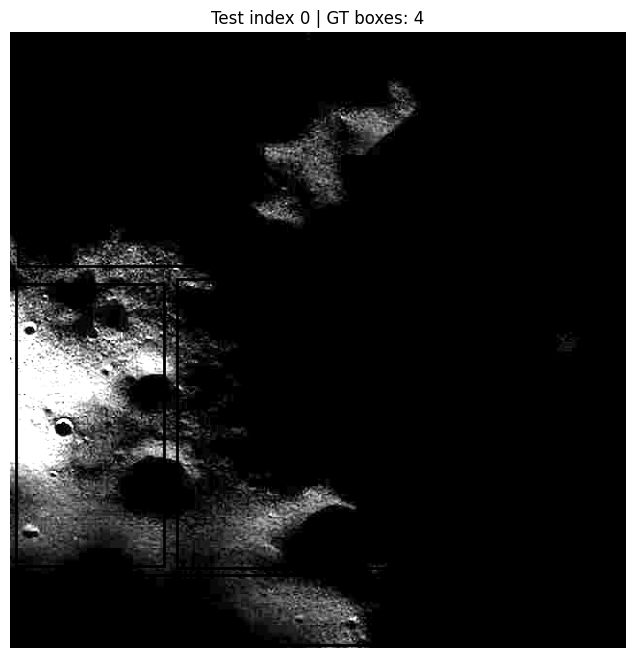

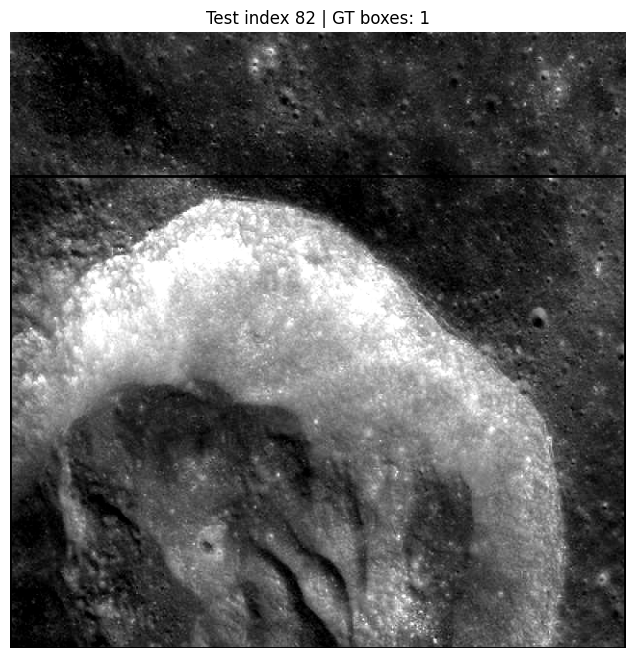

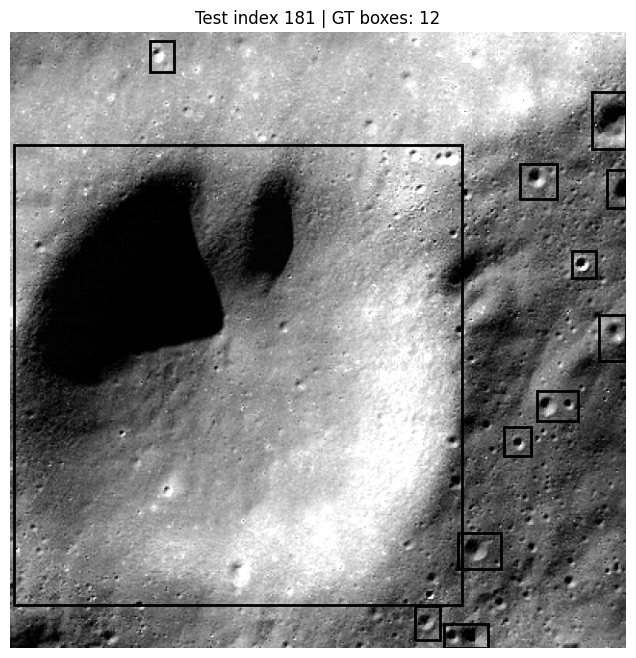

In [42]:
# Inspect three representative test images

indices = [0, 82, 181]

for idx in indices:

    image, target = test_dataset[idx]

    img = image.permute(1, 2, 0).numpy()
    gray = img.mean(axis=2)

    # Contrast enhancement for visualization
    low, high = np.percentile(gray, [2, 98])
    display_img = np.clip(
        (gray - low) / (high - low + 1e-8),
        0,
        1
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(display_img, cmap="gray")

    for box in target["boxes"]:
        x1, y1, x2, y2 = box.tolist()

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

    ax.set_title(
        f"Test index {idx} | GT boxes: {len(target['boxes'])}"
    )

    ax.axis("off")
    plt.show()

In [43]:
!find /content -iname "*.pth" -o -iname "*.pt"

/content/trained_model.pth
/content/checkpoints/epoch_12.pth
/content/checkpoints/epoch_11.pth
/content/checkpoints/epoch_6.pth
/content/checkpoints/epoch_18.pth
/content/checkpoints/best_model.pth
/content/checkpoints/epoch_4.pth
/content/checkpoints/epoch_2.pth
/content/checkpoints/epoch_8.pth
/content/checkpoints/epoch_14.pth
/content/checkpoints/epoch_19.pth
/content/checkpoints/epoch_9.pth
/content/checkpoints/epoch_1.pth
/content/checkpoints/epoch_17.pth
/content/checkpoints/epoch_7.pth
/content/checkpoints/epoch_16.pth
/content/checkpoints/epoch_20.pth
/content/checkpoints/epoch_3.pth
/content/checkpoints/epoch_15.pth
/content/checkpoints/epoch_13.pth
/content/checkpoints/epoch_10.pth
/content/checkpoints/epoch_5.pth


In [44]:
torch.save(
    model.state_dict(),
    "/content/crater_detector_best.pth"
)

print("✅ Detector saved")

✅ Detector saved


In [45]:
import os

print(
    "Detector exists:",
    os.path.exists("/content/crater_detector_best.pth")
)

print(
    "Size:",
    round(os.path.getsize("/content/crater_detector_best.pth") / (1024**2), 2),
    "MB"
)

Detector exists: True
Size: 72.52 MB


In [46]:
import shutil
import os

shutil.copy(
    "/content/checkpoints/best_model.pth",
    "/content/crater_detector_best.pth"
)

print("Exists:", os.path.exists("/content/crater_detector_best.pth"))


Exists: True


In [47]:
from google.colab import files

files.download("/content/crater_detector_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same Faster R-CNN architecture
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

# Load our saved best detector
checkpoint = torch.load(
    "/content/crater_detector_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("✅ CRATER DETECTOR LOADED")
print("Device:", device)
print("Parameters:", len(checkpoint))

FileNotFoundError: [Errno 2] No such file or directory: '/content/crater_detector_best.pth'

In [3]:
import os

print("Current /content files:")
print(os.listdir("/content"))

print("\nModel files:")
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".pth", ".pt")):
            print(os.path.join(root, file))

Current /content files:
['.config', 'sample_data']

Model files:


In [4]:
from google.colab import files

uploaded = files.upload()

Saving crater_detector_best.pth to crater_detector_best.pth


In [6]:
import os

print("Model exists:", os.path.exists("/content/crater_detector_best.pth"))
print("Size:", os.path.getsize("/content/crater_detector_best.pth") / (1024**2), "MB")

Model exists: True
Size: 72.5124158859253 MB


In [7]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

checkpoint = torch.load(
    "/content/crater_detector_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("✅ BEST MODEL LOADED")
print("Device:", device)
print("Classes: background + crater")

RuntimeError: Error(s) in loading state_dict for FasterRCNN:
	Missing key(s) in state_dict: "backbone.body.conv1.weight", "backbone.body.bn1.weight", "backbone.body.bn1.bias", "backbone.body.bn1.running_mean", "backbone.body.bn1.running_var", "backbone.body.layer1.0.conv1.weight", "backbone.body.layer1.0.bn1.weight", "backbone.body.layer1.0.bn1.bias", "backbone.body.layer1.0.bn1.running_mean", "backbone.body.layer1.0.bn1.running_var", "backbone.body.layer1.0.conv2.weight", "backbone.body.layer1.0.bn2.weight", "backbone.body.layer1.0.bn2.bias", "backbone.body.layer1.0.bn2.running_mean", "backbone.body.layer1.0.bn2.running_var", "backbone.body.layer1.0.conv3.weight", "backbone.body.layer1.0.bn3.weight", "backbone.body.layer1.0.bn3.bias", "backbone.body.layer1.0.bn3.running_mean", "backbone.body.layer1.0.bn3.running_var", "backbone.body.layer1.0.downsample.0.weight", "backbone.body.layer1.0.downsample.1.weight", "backbone.body.layer1.0.downsample.1.bias", "backbone.body.layer1.0.downsampl

In [8]:
print("CHECKPOINT FIRST 20 KEYS:")
for k in list(checkpoint.keys())[:20]:
    print(k)

print("\nCURRENT MODEL FIRST 20 KEYS:")
for k in list(model.state_dict().keys())[:20]:
    print(k)


CHECKPOINT FIRST 20 KEYS:
backbone.body.0.0.weight
backbone.body.0.1.weight
backbone.body.0.1.bias
backbone.body.0.1.running_mean
backbone.body.0.1.running_var
backbone.body.0.1.num_batches_tracked
backbone.body.1.block.0.0.weight
backbone.body.1.block.0.1.weight
backbone.body.1.block.0.1.bias
backbone.body.1.block.0.1.running_mean
backbone.body.1.block.0.1.running_var
backbone.body.1.block.0.1.num_batches_tracked
backbone.body.1.block.1.0.weight
backbone.body.1.block.1.1.weight
backbone.body.1.block.1.1.bias
backbone.body.1.block.1.1.running_mean
backbone.body.1.block.1.1.running_var
backbone.body.1.block.1.1.num_batches_tracked
backbone.body.2.block.0.0.weight
backbone.body.2.block.0.1.weight

CURRENT MODEL FIRST 20 KEYS:
backbone.body.conv1.weight
backbone.body.bn1.weight
backbone.body.bn1.bias
backbone.body.bn1.running_mean
backbone.body.bn1.running_var
backbone.body.bn1.num_batches_tracked
backbone.body.layer1.0.conv1.weight
backbone.body.layer1.0.bn1.weight
backbone.body.layer1.0

In [9]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
from torchvision.models._utils import IntermediateLayerGetter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build ResNet-50 backbone WITHOUT classification head
backbone_base = torchvision.models.resnet50(weights=None)

backbone = IntermediateLayerGetter(
    backbone_base,
    return_layers={"layer4": "0"}
)

backbone.out_channels = 2048

# Same type of RPN setup used by Faster R-CNN
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=7,
    sampling_ratio=2
)

model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

print("New model first 20 keys:")
for k in list(model.state_dict().keys())[:20]:
    print(k)

New model first 20 keys:
backbone.conv1.weight
backbone.bn1.weight
backbone.bn1.bias
backbone.bn1.running_mean
backbone.bn1.running_var
backbone.bn1.num_batches_tracked
backbone.layer1.0.conv1.weight
backbone.layer1.0.bn1.weight
backbone.layer1.0.bn1.bias
backbone.layer1.0.bn1.running_mean
backbone.layer1.0.bn1.running_var
backbone.layer1.0.bn1.num_batches_tracked
backbone.layer1.0.conv2.weight
backbone.layer1.0.bn2.weight
backbone.layer1.0.bn2.bias
backbone.layer1.0.bn2.running_mean
backbone.layer1.0.bn2.running_var
backbone.layer1.0.bn2.num_batches_tracked
backbone.layer1.0.conv3.weight
backbone.layer1.0.bn3.weight


In [10]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# EXACT architecture used by the trained checkpoint
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

checkpoint = torch.load(
    "/content/crater_detector_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("✅ BEST MODEL LOADED")
print("Device:", device)
print("Classes: background + crater")

✅ BEST MODEL LOADED
Device: cuda
Classes: background + crater


In [12]:
test_dataset = LunarDataset("/content/lunar_data/test")

print("Test images:", len(test_dataset))

NameError: name 'LunarDataset' is not defined

In [18]:
import zipfile
import os

zip_path = "/content/lunar.v3i.coco.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content")

print("Dataset exists:", os.path.exists("/content/lunar_data"))

if os.path.exists("/content/lunar_data"):
    print("Contents:", os.listdir("/content/lunar_data"))

Dataset exists: False


In [19]:
import os
import glob

print("ZIP files in /content:")
for f in glob.glob("/content/*.zip"):
    print(f)

ZIP files in /content:
/content/lunar.v3i.coco.zip


In [20]:
import zipfile

zip_path = "/content/lunar.v3i.coco.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("First 30 files inside ZIP:")
for name in names[:30]:
    print(name)

First 30 files inside ZIP:
README.dataset.txt
README.roboflow.txt
test/
test/_annotations.coco.json
test/ch2_tmc_ncn_20220101T0110303578_b_brw_d1832_jpeg.rf.aa5f8213f6d19efc912bf7255b4b35bf.jpg
test/ch2_tmc_ncn_20220101T0110303578_b_brw_d1852_jpeg.rf.b0a7e4ab9a2b4d408687817a77d8bd10.jpg
test/ch2_tmc_ncn_20220101T0308414328_b_brw_d1849_jpeg.rf.2d5f0090fee5e5d702f9c1099651508e.jpg
test/ch2_tmc_ncn_20220101T0308414328_b_brw_d1881_jpeg.rf.c81cb3cd4ec10348bbffa762a34ad252.jpg
test/ch2_tmc_ncn_20220102T0048587924_b_brw_d1862_jpeg.rf.1adccaf0808e0c3837f3b28d82850c28.jpg
test/ch2_tmc_ncn_20220102T0841479394_b_brw_d1841_jpeg.rf.fd738798bd1f3bad20813b00f0e69bb2.jpg
test/ch2_tmc_ncn_20220103T0225349470_b_brw_d1871_jpeg.rf.8acb08bbc39aae72cc5d97feb8b12450.jpg
test/ch2_tmc_ncn_20220103T0423479436_b_brw_d1845_jpeg.rf.7a799c3caf7f02ab3e19eb1cdca081c1.jpg
test/ch2_tmc_ncn_20220104T0402056549_b_brw_d1831_jpeg.rf.665f92b38b1194210369e1fedc6a2313.jpg
test/ch2_tmc_ncn_20220105T0349372204_b_brw_d1862_jpeg.

In [21]:
import zipfile
import os
import shutil

zip_path = "/content/lunar.v3i.coco.zip"

# Extract into a temporary location
extract_path = "/content/lunar_extracted"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

# Create the structure our existing code expects
os.makedirs("/content/lunar_data", exist_ok=True)

for folder in ["train", "valid", "test"]:
    src = os.path.join(extract_path, folder)
    dst = os.path.join("/content/lunar_data", folder)

    if os.path.exists(src):
        shutil.move(src, dst)

print("Dataset structure:")
for folder in ["train", "valid", "test"]:
    path = f"/content/lunar_data/{folder}"
    print(
        folder,
        "exists:", os.path.exists(path),
        "files:", len(os.listdir(path)) if os.path.exists(path) else 0
    )

Dataset structure:
train exists: True files: 1294
valid exists: True files: 372
test exists: True files: 185


In [22]:
test_dataset = LunarDataset("/content/lunar_data/test")

print("Test images:", len(test_dataset))

Test images: 184


In [25]:
# FINAL BASELINE EVALUATION
import torch
from torchvision.ops import box_iou

model.eval()

CONFIDENCE_THRESHOLD = 0.5

TP = 0
FP = 0
FN = 0

print("Evaluating BEST MODEL...")
print("Test images:", len(test_dataset))

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, target = test_dataset[idx]

        prediction = model([image.to(device)])[0]

        pred_boxes = prediction["boxes"].cpu()
        pred_scores = prediction["scores"].cpu()

        # Keep confident predictions
        keep = pred_scores >= CONFIDENCE_THRESHOLD

        pred_boxes = pred_boxes[keep]
        gt_boxes = target["boxes"]

        matched_gt = set()

        for pred_box in pred_boxes:

            if len(gt_boxes) == 0:
                FP += 1
                continue

            ious = box_iou(
                pred_box.unsqueeze(0),
                gt_boxes
            )[0]

            best_iou, best_idx = ious.max(0)

            if best_iou >= 0.5 and best_idx.item() not in matched_gt:
                TP += 1
                matched_gt.add(best_idx.item())
            else:
                FP += 1

        FN += len(gt_boxes) - len(matched_gt)

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{len(test_dataset)}")

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

print("\n" + "=" * 55)
print("FINAL BASELINE")
print("=" * 55)
print("True Positives :", TP)
print("False Positives:", FP)
print("False Negatives:", FN)
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print("=" * 55)

Evaluating BEST MODEL...
Test images: 184
Processed 20/184
Processed 40/184
Processed 60/184
Processed 80/184
Processed 100/184
Processed 120/184
Processed 140/184
Processed 160/184
Processed 180/184

FINAL BASELINE
True Positives : 0
False Positives: 0
False Negatives: 1546
Precision      : 0.0000
Recall         : 0.0000
F1 Score       : 0.0000


In [24]:
# Move the already-trained model to GPU
model = model.to(device)
model.eval()

print("Model device:", next(model.parameters()).device)
print("Input device:", device)

Model device: cuda:0
Input device: cuda


In [26]:
# Diagnose model output on ONE test image

model.eval()

image, target = test_dataset[0]

with torch.no_grad():
    prediction = model([image.to(device)])[0]

print("Number of predicted boxes:", len(prediction["boxes"]))

if len(prediction["scores"]) > 0:
    print("Top 20 scores:")
    print(prediction["scores"][:20].detach().cpu())

print("\nGT boxes:", len(target["boxes"]))
print("Predicted boxes shape:", prediction["boxes"].shape)

Number of predicted boxes: 100
Top 20 scores:
tensor([0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954,
        0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954, 0.4954,
        0.4954, 0.4954])

GT boxes: 4
Predicted boxes shape: torch.Size([100, 4])


In [27]:
print("Min score :", prediction["scores"].min().item())
print("Max score :", prediction["scores"].max().item())
print("Mean score:", prediction["scores"].mean().item())

print("\nUnique-ish scores:")
print(torch.unique(prediction["scores"].round(decimals=4))[:30])

Min score : 0.4954196810722351
Max score : 0.4954196810722351
Mean score: 0.4954196512699127

Unique-ish scores:
tensor([0.4954], device='cuda:0')


In [28]:
print("MODEL TYPE:")
print(type(model))

print("\nCLASSIFIER:")
print(model.roi_heads.box_predictor.cls_score)

print("\nBBOX PREDICTOR:")
print(model.roi_heads.box_predictor.bbox_pred)

MODEL TYPE:
<class 'torchvision.models.detection.faster_rcnn.FasterRCNN'>

CLASSIFIER:
Linear(in_features=1024, out_features=2, bias=True)

BBOX PREDICTOR:
Linear(in_features=1024, out_features=8, bias=True)


In [29]:
import torch

checkpoint = torch.load(
    "/content/crater_detector_best.pth",
    map_location="cpu"
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    keys = checkpoint.keys()
    print("Top-level keys:", list(keys)[:20])

    state_dict = checkpoint.get("model_state_dict", checkpoint)

    print("\nFirst 30 state-dict keys:")
    for k in list(state_dict.keys())[:30]:
        print(k)

Checkpoint type: <class 'collections.OrderedDict'>
Top-level keys: ['backbone.body.0.0.weight', 'backbone.body.0.1.weight', 'backbone.body.0.1.bias', 'backbone.body.0.1.running_mean', 'backbone.body.0.1.running_var', 'backbone.body.0.1.num_batches_tracked', 'backbone.body.1.block.0.0.weight', 'backbone.body.1.block.0.1.weight', 'backbone.body.1.block.0.1.bias', 'backbone.body.1.block.0.1.running_mean', 'backbone.body.1.block.0.1.running_var', 'backbone.body.1.block.0.1.num_batches_tracked', 'backbone.body.1.block.1.0.weight', 'backbone.body.1.block.1.1.weight', 'backbone.body.1.block.1.1.bias', 'backbone.body.1.block.1.1.running_mean', 'backbone.body.1.block.1.1.running_var', 'backbone.body.1.block.1.1.num_batches_tracked', 'backbone.body.2.block.0.0.weight', 'backbone.body.2.block.0.1.weight']

First 30 state-dict keys:
backbone.body.0.0.weight
backbone.body.0.1.weight
backbone.body.0.1.bias
backbone.body.0.1.running_mean
backbone.body.0.1.running_var
backbone.body.0.1.num_batches_tra

In [30]:
import torch
import torchvision

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the architecture used during training
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

# Load the EXISTING trained checkpoint
checkpoint = torch.load(
    "/content/crater_detector_best.pth",
    map_location=device
)

# Strict loading = every checkpoint weight must match
model.load_state_dict(checkpoint, strict=True)

model = model.to(device)
model.eval()

print("✅ CORRECT MODEL LOADED")
print("Architecture: Faster R-CNN + MobileNetV3-Large FPN")
print("Classes: background + crater")
print("Device:", next(model.parameters()).device)

✅ CORRECT MODEL LOADED
Architecture: Faster R-CNN + MobileNetV3-Large FPN
Classes: background + crater
Device: cuda:0


In [31]:
image, target = test_dataset[0]

with torch.no_grad():
    prediction = model([image.to(device)])[0]

print("Predicted boxes:", len(prediction["boxes"]))
print("Top 20 scores:")
print(prediction["scores"][:20].detach().cpu())
print("GT boxes:", len(target["boxes"]))

Predicted boxes: 5
Top 20 scores:
tensor([0.9053, 0.1698, 0.0987, 0.0743, 0.0610])
GT boxes: 4


In [32]:
CONFIDENCE_THRESHOLD = 0.5

tp = 0
fp = 0
fn = 0

print("Evaluating CORRECT BASELINE MODEL...")
print("Test images:", len(test_dataset))

model.eval()

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, target = test_dataset[idx]

        prediction = model([image.to(device)])[0]

        pred_boxes = prediction["boxes"].cpu()
        pred_scores = prediction["scores"].cpu()
        gt_boxes = target["boxes"].cpu()

        # Keep only confident predictions
        keep = pred_scores >= CONFIDENCE_THRESHOLD
        pred_boxes = pred_boxes[keep]

        # Match predictions to GT using IoU
        matched_gt = set()

        for pred_box in pred_boxes:

            best_iou = 0
            best_gt = -1

            for gt_idx, gt_box in enumerate(gt_boxes):

                if gt_idx in matched_gt:
                    continue

                # IoU
                x1 = max(pred_box[0], gt_box[0])
                y1 = max(pred_box[1], gt_box[1])
                x2 = min(pred_box[2], gt_box[2])
                y2 = min(pred_box[3], gt_box[3])

                inter_w = max(0, x2 - x1)
                inter_h = max(0, y2 - y1)
                inter = inter_w * inter_h

                pred_area = (
                    (pred_box[2] - pred_box[0]) *
                    (pred_box[3] - pred_box[1])
                )

                gt_area = (
                    (gt_box[2] - gt_box[0]) *
                    (gt_box[3] - gt_box[1])
                )

                union = pred_area + gt_area - inter

                iou = inter / union if union > 0 else 0

                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt_idx

            if best_iou >= 0.5:
                tp += 1
                matched_gt.add(best_gt)
            else:
                fp += 1

        fn += len(gt_boxes) - len(matched_gt)

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{len(test_dataset)}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0 else 0
)

print("\n" + "=" * 55)
print("CORRECT BASELINE RESULTS")
print("=" * 55)
print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print("=" * 55)

Evaluating CORRECT BASELINE MODEL...
Test images: 184
Processed 20/184
Processed 40/184
Processed 60/184
Processed 80/184
Processed 100/184
Processed 120/184
Processed 140/184
Processed 160/184
Processed 180/184

CORRECT BASELINE RESULTS
True Positives : 369
False Positives: 1032
False Negatives: 1177
Precision      : 0.2634
Recall         : 0.2387
F1 Score       : 0.2504


In [34]:
import os

print(os.listdir("/content"))

['.config', 'lunar.v3i.coco.zip', 'lunar_extracted', 'test', 'crater_detector_best.pth', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'lunar_data', 'valid', 'sample_data']


In [35]:
from google.colab import files

uploaded = files.upload()

print("Uploaded:", list(uploaded.keys()))

Saving lunar_step_5000 (1).pth.zip to lunar_step_5000 (1).pth.zip
Uploaded: ['lunar_step_5000 (1).pth.zip']


In [36]:
import os
import glob

print("SR files found:")

for f in glob.glob("/content/*"):
    if f.endswith((".pth", ".pt", ".zip")):
        print(f)

SR files found:
/content/lunar.v3i.coco.zip
/content/lunar_step_5000 (1).pth.zip
/content/crater_detector_best.pth


In [37]:
import zipfile
import os
import glob

zip_path = "/content/lunar_step_5000 (1).pth.zip"
extract_dir = "/content/sr_weights"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("✅ SR checkpoint extracted")

for f in glob.glob("/content/sr_weights/**/*", recursive=True):
    if os.path.isfile(f):
        print(f)

✅ SR checkpoint extracted
/content/sr_weights/lunar_step_5000/version
/content/sr_weights/lunar_step_5000/data.pkl
/content/sr_weights/lunar_step_5000/byteorder
/content/sr_weights/lunar_step_5000/data/257
/content/sr_weights/lunar_step_5000/data/327
/content/sr_weights/lunar_step_5000/data/540
/content/sr_weights/lunar_step_5000/data/250
/content/sr_weights/lunar_step_5000/data/107
/content/sr_weights/lunar_step_5000/data/115
/content/sr_weights/lunar_step_5000/data/472
/content/sr_weights/lunar_step_5000/data/539
/content/sr_weights/lunar_step_5000/data/153
/content/sr_weights/lunar_step_5000/data/569
/content/sr_weights/lunar_step_5000/data/311
/content/sr_weights/lunar_step_5000/data/393
/content/sr_weights/lunar_step_5000/data/632
/content/sr_weights/lunar_step_5000/data/191
/content/sr_weights/lunar_step_5000/data/466
/content/sr_weights/lunar_step_5000/data/204
/content/sr_weights/lunar_step_5000/data/558
/content/sr_weights/lunar_step_5000/data/364
/content/sr_weights/lunar_ste

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

class ResidualDenseBlock(nn.Module):
    def __init__(self, num_feat=64, num_grow_ch=32):
        super().__init__()
        self.conv1 = nn.Conv2d(num_feat, num_grow_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_feat + num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_feat + 2*num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_feat + 3*num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_feat + 4*num_grow_ch, num_feat, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    def __init__(self, num_feat=64, num_grow_ch=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb2 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb3 = ResidualDenseBlock(num_feat, num_grow_ch)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x


class RRDBNet(nn.Module):
    def __init__(
        self,
        num_in_ch=3,
        num_out_ch=3,
        scale=4,
        num_feat=64,
        num_block=23,
        num_grow_ch=32
    ):
        super().__init__()

        self.scale = scale

        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)

        self.body = nn.Sequential(
            *[RRDB(num_feat, num_grow_ch) for _ in range(num_block)]
        )

        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)

        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat

        feat = self.lrelu(
            self.conv_up1(
                F.interpolate(feat, scale_factor=2, mode="nearest")
            )
        )

        feat = self.lrelu(
            self.conv_up2(
                F.interpolate(feat, scale_factor=2, mode="nearest")
            )
        )

        out = self.conv_last(self.lrelu(self.conv_hr(feat)))

        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sr_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    scale=4,
    num_feat=64,
    num_block=23,
    num_grow_ch=32
)

checkpoint_path = "/content/sr_weights/lunar_step_5000"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint loaded:", type(checkpoint))
print("Keys:", checkpoint.keys() if isinstance(checkpoint, dict) else "not a dict")

IsADirectoryError: [Errno 21] Is a directory: '/content/sr_weights/lunar_step_5000'

In [39]:
import os

root = "/content/sr_weights/lunar_step_5000"

print("Contents:")
for f in os.listdir(root):
    print(f)

Contents:
data
version
.data
.format_version
data.pkl
.storage_alignment
byteorder


In [41]:
import zipfile
import os
import torch

src = "/content/sr_weights/lunar_step_5000"
fixed_zip = "/content/lunar_step_5000_fixed.pth"

# Create the archive with the required internal folder
with zipfile.ZipFile(fixed_zip, "w") as z:
    for root, dirs, files in os.walk(src):
        for file in files:
            full_path = os.path.join(root, file)

            # Everything goes under lunar_step_5000/
            relative = os.path.relpath(full_path, src)
            arcname = os.path.join("lunar_step_5000", relative)

            z.write(full_path, arcname)

print("✅ Checkpoint rebuilt correctly")

# Now try loading
checkpoint = torch.load(
    fixed_zip,
    map_location=device
)

print("✅ SR CHECKPOINT LOADED!")
print("Type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Keys:", list(checkpoint.keys())[:20])

✅ Checkpoint rebuilt correctly
✅ SR CHECKPOINT LOADED!
Type: <class 'collections.OrderedDict'>
Keys: ['conv_first.weight', 'conv_first.bias', 'body.0.rdb1.conv1.weight', 'body.0.rdb1.conv1.bias', 'body.0.rdb1.conv2.weight', 'body.0.rdb1.conv2.bias', 'body.0.rdb1.conv3.weight', 'body.0.rdb1.conv3.bias', 'body.0.rdb1.conv4.weight', 'body.0.rdb1.conv4.bias', 'body.0.rdb1.conv5.weight', 'body.0.rdb1.conv5.bias', 'body.0.rdb2.conv1.weight', 'body.0.rdb2.conv1.bias', 'body.0.rdb2.conv2.weight', 'body.0.rdb2.conv2.bias', 'body.0.rdb2.conv3.weight', 'body.0.rdb2.conv3.bias', 'body.0.rdb2.conv4.weight', 'body.0.rdb2.conv4.bias']


In [42]:
sr_model.load_state_dict(checkpoint, strict=True)

sr_model = sr_model.to(device)
sr_model.eval()

print("✅ SR MODEL READY")
print("Device:", device)
print("Parameters:", sum(p.numel() for p in sr_model.parameters()))

✅ SR MODEL READY
Device: cuda
Parameters: 16697987


Original: (640, 640, 3)
SR: (2560, 2560, 3)


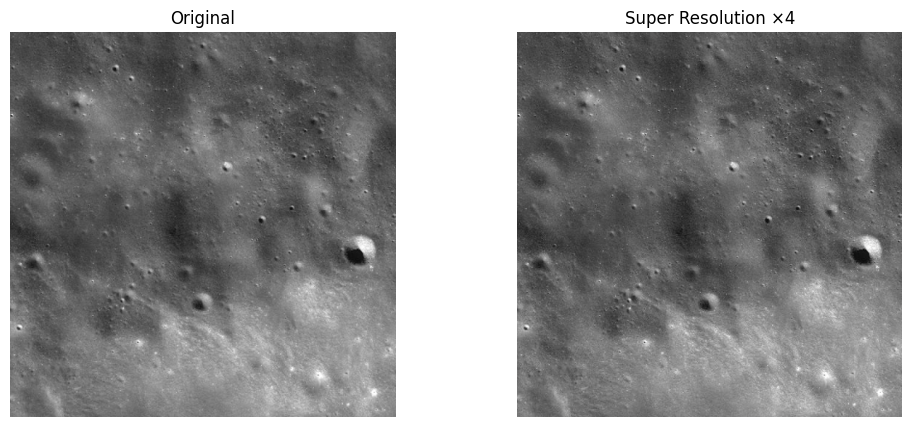

In [43]:
import cv2
import matplotlib.pyplot as plt
import torch

# Pick one test image
img_path = "/content/test/" + os.listdir("/content/test")[0]

img = cv2.imread(img_path)

# BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Prepare for SR
sr_input = torch.from_numpy(
    img_rgb.astype("float32") / 255.0
).permute(2, 0, 1).unsqueeze(0).to(device)

# Run SR
with torch.no_grad():
    sr_output = sr_model(sr_input)

# Convert back to image
sr_output = sr_output.squeeze(0).cpu().clamp(0, 1)
sr_image = sr_output.permute(1, 2, 0).numpy()

print("Original:", img_rgb.shape)
print("SR:", sr_image.shape)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sr_image)
plt.title("Super Resolution ×4")
plt.axis("off")

plt.show()

SR image: (2560, 2560, 3)
Detector input after SR: (640, 640, 3)


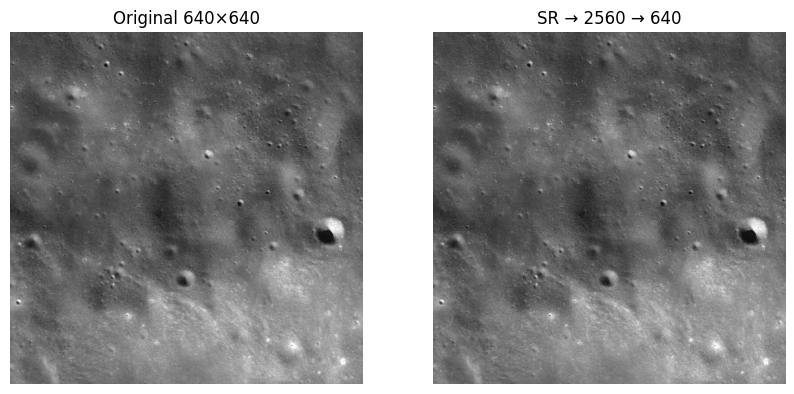

In [44]:
# SR -> resize back to detector input size

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# SR
sr_input = torch.from_numpy(
    img_rgb.astype(np.float32) / 255.0
).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    sr_output = sr_model(sr_input)

sr_image = (
    sr_output.squeeze(0)
    .cpu()
    .clamp(0, 1)
    .permute(1, 2, 0)
    .numpy()
)

# Back to detector's 640x640 input
sr_640 = cv2.resize(
    (sr_image * 255).astype(np.uint8),
    (640, 640),
    interpolation=cv2.INTER_AREA
)

print("SR image:", sr_image.shape)
print("Detector input after SR:", sr_640.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original 640×640")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sr_640)
plt.title("SR → 2560 → 640")
plt.axis("off")

plt.show()

In [45]:
import cv2
import numpy as np
import torch
from tqdm import tqdm

print("Evaluating SR → Detector...")
print("Test images:", len(test_dataset))

all_tp = 0
all_fp = 0
all_fn = 0

for idx in tqdm(range(len(test_dataset))):

    image, target = test_dataset[idx]

    # Get original image as numpy
    img = image.permute(1, 2, 0).cpu().numpy()

    # Normalize to 0-255
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    # SR input
    sr_input = torch.from_numpy(
        img.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    # Super-resolution
    with torch.no_grad():
        sr_output = sr_model(sr_input)

    # Convert SR output to numpy
    sr_image = (
        sr_output.squeeze(0)
        .cpu()
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

    # Resize back to detector input size
    sr_640 = cv2.resize(
        (sr_image * 255).astype(np.uint8),
        (640, 640),
        interpolation=cv2.INTER_AREA
    )

    # Detector input
    detector_input = (
        torch.from_numpy(sr_640.astype(np.float32) / 255.0)
        .permute(2, 0, 1)
        .to(device)
    )

    # Detector prediction
    with torch.no_grad():
        prediction = model([detector_input])[0]

    pred_boxes = prediction["boxes"].cpu()
    pred_scores = prediction["scores"].cpu()

    # Keep predictions above our chosen threshold
    keep = pred_scores >= 0.50
    pred_boxes = pred_boxes[keep]

    gt_boxes = target["boxes"].cpu()

    # IoU matching
    matched_gt = set()
    tp = 0
    fp = 0

    for pred_box in pred_boxes:

        if len(gt_boxes) == 0:
            fp += 1
            continue

        best_iou = 0
        best_gt = -1

        px1, py1, px2, py2 = pred_box

        for j, gt_box in enumerate(gt_boxes):

            if j in matched_gt:
                continue

            gx1, gy1, gx2, gy2 = gt_box

            ix1 = max(px1, gx1)
            iy1 = max(py1, gy1)
            ix2 = min(px2, gx2)
            iy2 = min(py2, gy2)

            inter_w = max(0, ix2 - ix1)
            inter_h = max(0, iy2 - iy1)
            inter = inter_w * inter_h

            pred_area = max(0, px2 - px1) * max(0, py2 - py1)
            gt_area = max(0, gx2 - gx1) * max(0, gy2 - gy1)

            union = pred_area + gt_area - inter

            iou = inter / union if union > 0 else 0

            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= 0.50:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    all_tp += tp
    all_fp += fp
    all_fn += fn


precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) else 0
recall = all_tp / (all_tp + all_fn) if (all_tp + all_fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

print("\n" + "=" * 55)
print("SR → DETECTOR RESULTS")
print("=" * 55)
print("True Positives :", all_tp)
print("False Positives:", all_fp)
print("False Negatives:", all_fn)
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("\nBASELINE F1    : 0.2504")
print(f"SR MODEL F1    : {f1:.4f}")
print(f"F1 CHANGE      : {f1 - 0.2504:+.4f}")

Evaluating SR → Detector...
Test images: 184


100%|██████████| 184/184 [14:47<00:00,  4.82s/it]


SR → DETECTOR RESULTS
True Positives : 363
False Positives: 989
False Negatives: 1183
Precision      : 0.2685
Recall         : 0.2348
F1 Score       : 0.2505

BASELINE F1    : 0.2504
SR MODEL F1    : 0.2505
F1 CHANGE      : +0.0001


In [46]:
import cv2
import numpy as np

def detect_shadows(img: np.ndarray, low_thresh: int = 40) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    shadow_mask = (gray < low_thresh).astype(np.float32)
    return shadow_mask


def estimate_slopes(img: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img

    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    grad_mag = np.sqrt(sobelx**2 + sobely**2)

    norm_slope = (
        (grad_mag - grad_mag.min()) /
        (grad_mag.max() - grad_mag.min() + 1e-6)
    )

    return norm_slope.astype(np.float32)

In [47]:
import matplotlib.pyplot as plt

image, target = test_dataset[0]

# Convert tensor → image
img = image.permute(1, 2, 0).cpu().numpy()

if img.max() <= 1.0:
    img = (img * 255).astype(np.uint8)
else:
    img = img.astype(np.uint8)

# RGB → BGR for OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

shadow_mask = detect_shadows(img_bgr)
slope_mask = estimate_slopes(img_bgr)

print("Image:", img.shape)
print("Shadow mask:", shadow_mask.shape)
print("Slope map:", slope_mask.shape)

Image: (640, 640, 3)
Shadow mask: (640, 640)
Slope map: (640, 640)


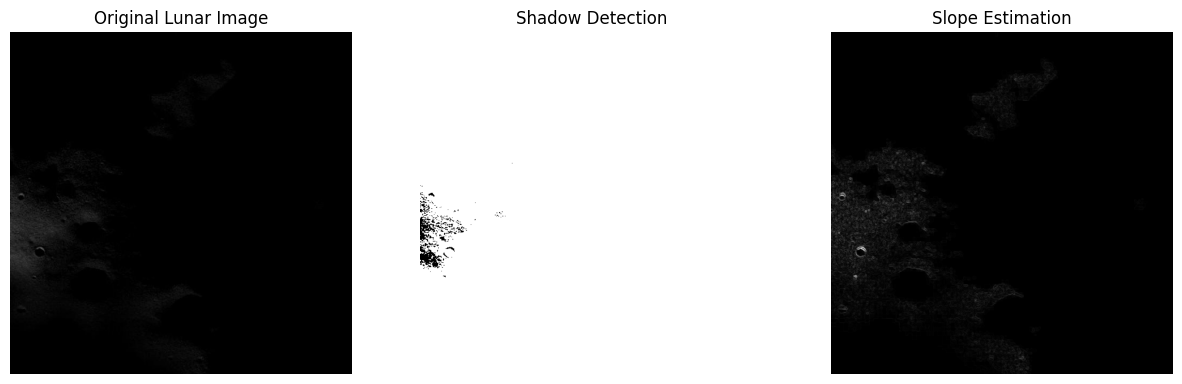

In [48]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Lunar Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(shadow_mask, cmap="gray")
plt.title("Shadow Detection")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(slope_mask, cmap="gray")
plt.title("Slope Estimation")
plt.axis("off")

plt.show()

In [49]:
print("Image min:", img.min())
print("Image max:", img.max())
print("Image mean:", img.mean())

print("Shadow pixels:", np.sum(shadow_mask))
print("Shadow %:", 100 * np.mean(shadow_mask))

print("Slope min:", slope_mask.min())
print("Slope max:", slope_mask.max())
print("Slope mean:", slope_mask.mean())

Image min: 0
Image max: 110
Image mean: 2.10345947265625
Shadow pixels: 407014.0
Shadow %: 99.36865
Slope min: 0.0
Slope max: 1.0
Slope mean: 0.011507081


In [50]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Gray percentiles:")
for p in [1, 5, 10, 15, 20, 25, 50, 75, 90, 95, 99]:
    print(f"{p}%:", np.percentile(gray, p))

Gray percentiles:
1%: 0.0
5%: 0.0
10%: 0.0
15%: 0.0
20%: 0.0
25%: 0.0
50%: 0.0
75%: 0.0
90%: 7.0
95%: 13.0
99%: 36.0


In [51]:
# Adaptive shadow detection
def detect_shadows_adaptive(img: np.ndarray, percentile: float = 10) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img

    threshold = np.percentile(gray, percentile)

    shadow_mask = (gray <= threshold).astype(np.float32)

    return shadow_mask


shadow_mask = detect_shadows_adaptive(img_bgr, percentile=10)

print("Adaptive shadow threshold:", np.percentile(gray, 10))
print("Shadow pixels:", np.sum(shadow_mask))
print("Shadow %:", 100 * np.mean(shadow_mask))

Adaptive shadow threshold: 0.0
Shadow pixels: 321572.0
Shadow %: 78.50879


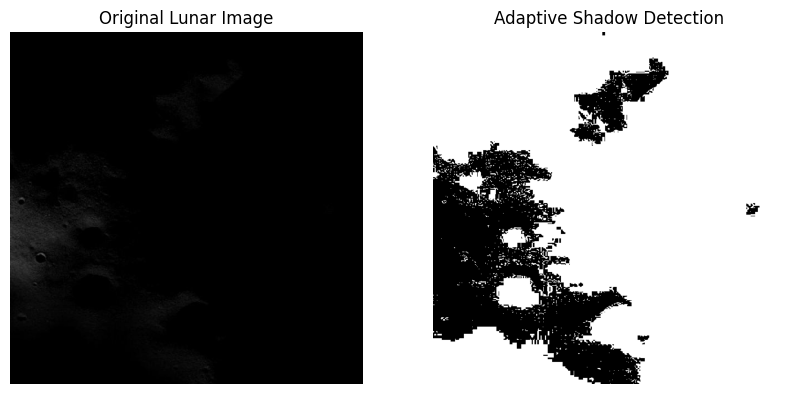

In [54]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Lunar Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(shadow_mask, cmap="gray")
plt.title("Adaptive Shadow Detection")
plt.axis("off")

plt.show()

In [64]:
# ================================
# FINAL HAZARD ANALYSIS PIPELINE
# ================================

# Get crater detections
with torch.no_grad():
    prediction = model([image.to(device)])[0]

scores = prediction["scores"].detach().cpu().numpy()
boxes = prediction["boxes"].detach().cpu().numpy()

# Keep reasonably confident detections
keep = scores >= 0.30
filtered_boxes = boxes[keep]

print("Crater detections:", len(filtered_boxes))

# Make sure masks correspond to 640x640 detector image
h, w = img.shape[:2]

shadow_mask_final = cv2.resize(
    shadow_mask,
    (w, h),
    interpolation=cv2.INTER_NEAREST
)

slope_mask_final = cv2.resize(
    slope_mask,
    (w, h),
    interpolation=cv2.INTER_LINEAR
)

# Create risk map
risk_map = compute_risk_map(
    img,
    shadow_mask_final,
    slope_mask_final,
    filtered_boxes
)

print("Risk map:", risk_map.shape)
print("Risk range:", risk_map.min(), "to", risk_map.max())
print("Average risk:", risk_map.mean())

# Find safe zones
safe_zones = find_safe_zones(
    risk_map,
    risk_threshold=0.30,
    min_zone_area_px=400,
    top_n=5
)

print("\n================================")
print("SAFE LANDING ZONES")
print("================================")

for zone in safe_zones:
    print(zone)

recommended = get_recommended_zone_id(safe_zones)

print("\nRecommended landing zone:", recommended)

Crater detections: 1
Risk map: (640, 640)
Risk range: 0.0 to 0.88561434
Average risk: 0.24410936

SAFE LANDING ZONES
{'id': 'zone_1', 'x': 331, 'y': 125, 'radius_px': 56.7, 'risk_score': 0.012, 'rank': 1, 'area_m2': 10105}
{'id': 'zone_2', 'x': 148, 'y': 432, 'radius_px': 150.7, 'risk_score': 0.015, 'rank': 2, 'area_m2': 71330}

Recommended landing zone: zone_1


In [63]:
import numpy as np
from scipy import ndimage

def find_safe_zones(
    risk_map,
    risk_threshold=0.3,
    min_zone_area_px=400,
    top_n=5
):
    safe_mask = risk_map < risk_threshold

    labeled_array, num_features = ndimage.label(safe_mask)

    candidates = []

    for label_id in range(1, num_features + 1):

        blob_coords = np.argwhere(
            labeled_array == label_id
        )

        area_px = len(blob_coords)

        if area_px < min_zone_area_px:
            continue

        centroid_y, centroid_x = blob_coords.mean(axis=0)

        radius_px = np.sqrt(area_px / np.pi)

        blob_risk_values = risk_map[
            labeled_array == label_id
        ]

        avg_risk_score = float(
            blob_risk_values.mean()
        )

        candidates.append({
            "x": int(centroid_x),
            "y": int(centroid_y),
            "radius_px": float(round(radius_px, 1)),
            "risk_score": round(avg_risk_score, 3),
            "area_px": area_px
        })

    candidates.sort(
        key=lambda c: (
            c["risk_score"],
            -c["area_px"]
        )
    )

    ranked_zones = []

    for i, c in enumerate(candidates[:top_n]):

        ranked_zones.append({
            "id": f"zone_{i+1}",
            "x": c["x"],
            "y": c["y"],
            "radius_px": c["radius_px"],
            "risk_score": c["risk_score"],
            "rank": i + 1,
            "area_m2": c["area_px"]
        })

    return ranked_zones


def get_recommended_zone_id(safe_zones):

    return safe_zones[0]["id"] if safe_zones else None


print("✅ Safe-zone functions ready")

✅ Safe-zone functions ready


In [61]:
import numpy as np
import cv2

def compute_risk_map(
    enhanced_img,
    shadow_mask,
    slope_mask,
    boxes=None
):
    h, w = enhanced_img.shape[:2]

    crater_mask = np.zeros((h, w), dtype=np.float32)

    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box[:4])

            x1 = max(0, min(x1, w - 1))
            x2 = max(0, min(x2, w - 1))
            y1 = max(0, min(y1, h - 1))
            y2 = max(0, min(y2, h - 1))

            cv2.rectangle(
                crater_mask,
                (x1, y1),
                (x2, y2),
                1.0,
                -1
            )

    risk_map = (
        0.4 * crater_mask +
        0.3 * shadow_mask +
        0.3 * slope_mask
    )

    return np.clip(risk_map, 0.0, 1.0)

print("✅ Risk-map function ready")

✅ Risk-map function ready


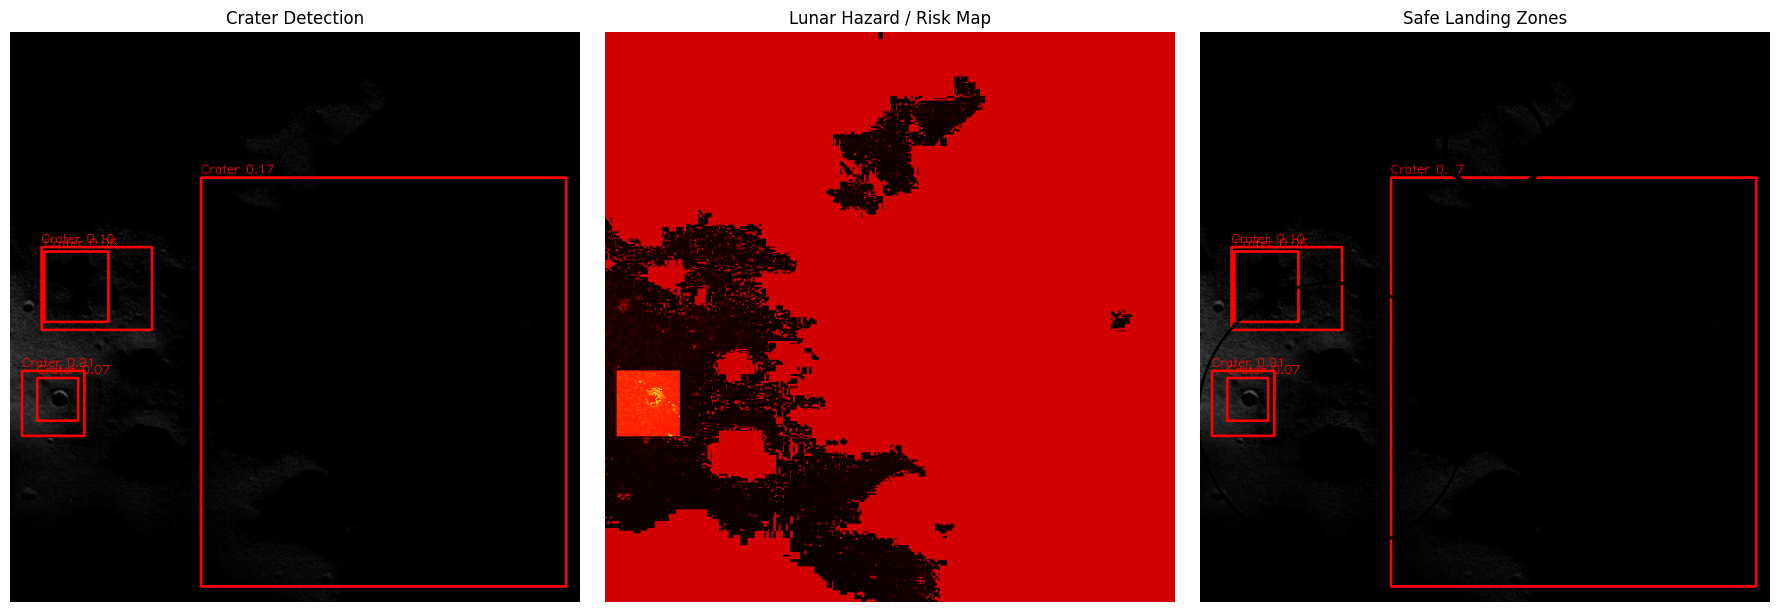


FINAL LUNAR LANDING ANALYSIS
Crater detections: 5
Safe zones found: 2
Recommended landing zone: zone_1
Recommended coordinates: (331, 125)
Risk score: 0.012


In [65]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ============================================================
# FINAL VISUALIZATION
# ============================================================

# Original image
final_img = img.copy()

# Convert grayscale if needed
if len(final_img.shape) == 2:
    final_img = cv2.cvtColor(final_img, cv2.COLOR_GRAY2RGB)
else:
    final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

# ------------------------------------------------------------
# 1. Draw crater detections
# ------------------------------------------------------------

if "prediction" in globals():
    boxes = prediction["boxes"].detach().cpu().numpy()
    scores = prediction["scores"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()

    # Keep detections above threshold
    keep = scores >= 0.05

    boxes = boxes[keep]
    scores = scores[keep]

    for box, score in zip(boxes, scores):

        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(
            final_img,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        cv2.putText(
            final_img,
            f"Crater {score:.2f}",
            (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 0, 0),
            1
        )

# ------------------------------------------------------------
# 2. Plot final hazard/risk map
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original + detections
axes[0].imshow(final_img)
axes[0].set_title("Crater Detection")
axes[0].axis("off")

# Risk map
axes[1].imshow(risk_map, cmap="hot", vmin=0, vmax=1)
axes[1].set_title("Lunar Hazard / Risk Map")
axes[1].axis("off")

# Final landing zones
axes[2].imshow(final_img)

for zone in safe_zones:

    x = zone["x"]
    y = zone["y"]
    radius = zone["radius_px"]

    # Draw safe-zone circle
    circle = plt.Circle(
        (x, y),
        radius,
        fill=False,
        linewidth=2
    )

    axes[2].add_patch(circle)

    axes[2].text(
        x,
        y,
        zone["id"],
        fontsize=10,
        ha="center",
        va="center"
    )

# Highlight recommended zone
if recommended is not None:

    selected = next(
        (z for z in safe_zones if z["id"] == recommended),
        None
    )

    if selected is not None:

        x = selected["x"]
        y = selected["y"]
        radius = selected["radius_px"]

        circle = plt.Circle(
            (x, y),
            radius,
            fill=False,
            linewidth=4
        )

        axes[2].add_patch(circle)

        axes[2].text(
            x,
            y - radius - 10,
            "RECOMMENDED LANDING ZONE",
            fontsize=11,
            ha="center"
        )

axes[2].set_title("Safe Landing Zones")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("FINAL LUNAR LANDING ANALYSIS")
print("=" * 55)

print("Crater detections:", len(boxes))
print("Safe zones found:", len(safe_zones))
print("Recommended landing zone:", recommended)

if recommended is not None:
    selected = next(
        z for z in safe_zones
        if z["id"] == recommended
    )

    print("Recommended coordinates:",
          (selected["x"], selected["y"]))

    print("Risk score:",
          selected["risk_score"])

print("=" * 55)

In [67]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [68]:
from google.colab import files

files.download("/content/crater_detector_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
from google.colab import files

files.download("/content/lunar_step_5000_fixed.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import os

for f in [
    "/content/crater_detector_best.pth",
    "/content/lunar_step_5000_fixed.pth"
]:
    print(f, "→", os.path.exists(f))

/content/crater_detector_best.pth → True
/content/lunar_step_5000_fixed.pth → True
